# PHASE 3
# FEATURE EXTRACTION FOR BraTS2021
# Stability-Filtered Radiomic Features from Predicted and Ground-Truth Masks

This notebook turns the Phase 2 segmentation masks into a compact, stability-filtered feature table. Features are extracted from both the predicted and the ground-truth masks and compared, so each feature's robustness to segmentation error is measured rather than assumed. Quantities are computed per patient for three subregions - ET, TC, WT - on the most relevant modality per subregion (T1ce for ET/TC, FLAIR for WT).

Quantities produced:
- **PyRadiomics features** - shape, first-order intensity, and texture, from the `Original` (unfiltered) image only.
- **Volumetric ratios** - dimensionless quantities (ET/WT, ET/TC, TC/WT, necrosis fraction, edema index).

## Overview

This notebook proceeds in four stages:

1. **Setup & pilot**: configuration, helpers, a spacing check, and a small pilot smoke test of the extraction pipeline.
2. **Full extraction**: radiomic features extracted from GT and predicted masks for all validation patients with skip logging.
3. **Selection**: ICC(2,1) stability filter, correlation pruning, texture exclusion and a clinical-reporting filter that scopes out scanner-dependent absolute-intensity features.
4. **Derived quantities & summary**: volume ratios (stability-gated like the features) and descriptive statistics of the final set.

The frozen feature list (`report_features.json`) feeds the report layer (Phase 5).

The pipeline is parametric: the stability and redundancy thresholds, the interpretable feature classes, the ratio set and the pilot/diagnostic sizes are set in the configuration cell and can be changed without modifying the extraction or selection code.

In [1]:
import warnings 
warnings.filterwarnings("ignore")

## 1. Imports and logging setup

Initialize the PyRadiomics logger and configure its verbosity and propagation settings to suppress per-feature debug noise in the notebook output.

In [2]:
from __future__ import annotations

import logging
import os
import json

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
import seaborn as sns
import SimpleITK as sitk
from scipy import stats, ndimage
from collections import defaultdict
import radiomics
from radiomics import featureextractor, getFeatureClasses

%matplotlib inline

# Get the PyRadiomics logger
logger = radiomics.logger
logger.setLevel(logging.WARNING)    # quiet: keep only warnings/errors in the log file
logger.propagate = False

print("PyRadiomics version:", radiomics.__version__)

MIN_SUBREGION_VOXELS = 10   # subregions smaller than this are skipped (affects ET dropout count)

PyRadiomics version: v3.0.1


## 2. Data paths and directory setup

Set paths for the BraTS21 dataset root, the predicted masks from Swin-UNETR inference, the output directory for extracted features, the PyRadiomics parameter file and the log file.

In [3]:
# Define Paths
notebook_dir = os.getcwd()
project_root = os.path.dirname(notebook_dir)

data_dir = os.path.join(project_root, "data", "BraTS21", "BraTS2021_Training_Data", "TrainingData")
output_dir = os.path.join(project_root, "outputs", "feature_outputs")
masks_dir = os.path.join(project_root, "outputs", "outputs_full_finetuning", "predicted_masks")
params_file = os.path.join(project_root, "notebooks", "Params.yaml")
logs_path = os.path.join(project_root, "logs", "feature_extraction.log")

# Create Directories
os.makedirs(output_dir, exist_ok=True)
os.makedirs(os.path.dirname(logs_path), exist_ok=True)

# Configure the log file handler
handler = logging.FileHandler(filename=logs_path, mode='w')
formatter = logging.Formatter('%(levelname)s:%(name)s: %(message)s')
handler.setFormatter(formatter)
logger.addHandler(handler)

# 4. Print Status
print("Data dir:", data_dir)
print("Output dir:", output_dir)
print("Masks dir:", masks_dir)
print("Params file exists:", os.path.exists(params_file))
print("Logging to:", logs_path)

Data dir: c:\Users\Usuario\Nikolina_TFM\data\BraTS21\BraTS2021_Training_Data\TrainingData
Output dir: c:\Users\Usuario\Nikolina_TFM\outputs\feature_outputs
Masks dir: c:\Users\Usuario\Nikolina_TFM\outputs\outputs_full_finetuning\predicted_masks
Params file exists: True
Logging to: c:\Users\Usuario\Nikolina_TFM\logs\feature_extraction.log


## 3. Configuration

Tunable parameters for this run.

In [4]:
# Configuration - tunable parameters for this run

# Pilot/diagnostic sample sizes (pipeline checks only, do not affect the full run)
n_pilot = 10            # patients for the pilot smoke test
n_diag  = 30            # patients for the read-only post-processing diagnostic

# Feature extraction
MIN_SUBREGION_VOXELS = 10   # subregions smaller than this are skipped (affects ET dropout count)

# Feature selection
ICC_THRESHOLD = 0.75  # keep features with ICC (or its 95% CI lower bound) above this
CORR_THRESHOLD = 0.80  # drop one feature from each pair with |r| above this
USE_CI_LOWER_BOUND = True  # if True, apply ICC_THRESHOLD to the CI lower bound

INTERPRETABLE_CLASSES = {"shape", "firstorder"}   # feature classes kept as clinically interpretable

# Rule (not a fixed list): first-order features whose names contain these keys are treated as
# absolute-intensity (scanner-dependent) and excluded from reporting. Works for any feature set.
ABSOLUTE_INTENSITY_KEYS = ["RootMeanSquared", "90Percentile", "10Percentile", "Mean", "Median",
                           "Energy", "TotalEnergy", "Maximum", "Minimum", "Range",
                           "InterquartileRange", "MeanAbsoluteDeviation",
                           "RobustMeanAbsoluteDeviation", "Variance"]

RATIO_COLS = ["ET_WT_ratio", "ET_TC_ratio", "TC_WT_ratio", "necrosis_fraction", "edema_index"]


## 4. Extractor settings

The extractor is built directly from `Params.yaml` (param-file approach), based on the stock PyRadiomics example file.

Key choices:
- `resampledPixelSpacing = None` - BraTS21 is already 1 mm isotropic.
- `normalize = False` - intensities are left in their native scale; MONAI normalisation is a training transform only and is not applied for feature extraction.
- `label = 1` - the extractor reads the foreground of the **binary subregion mask** built per subregion in `get_binary_mask_sitk`, it is not the raw BraTS label 1.

Only the `Original` image type is used - LoG/Wavelet-filtered features were excluded because they are less interpretable and less reproducible, which conflicts with the goal of a clinically legible, stable feature set.

In [5]:
# Extractor built from the parameter file.
# All extraction settings  (binWidth, resampledPixelSpacing, interpolator, minimumROIDimensions, minimumROISize) are in Params.yaml.
extractor = featureextractor.RadiomicsFeatureExtractor(params_file)

print('Extraction parameters:\n\t', extractor.settings)
print('\nEnabled filters:\n\t', extractor.enabledImagetypes)
print('\nEnabled features:\n\t', extractor.enabledFeatures)

Extraction parameters:
	 {'minimumROIDimensions': 2, 'minimumROISize': None, 'normalize': False, 'normalizeScale': 1, 'removeOutliers': None, 'resampledPixelSpacing': None, 'interpolator': 'sitkBSpline', 'preCrop': False, 'padDistance': 5, 'distances': [1], 'force2D': False, 'force2Ddimension': 0, 'resegmentRange': None, 'label': 1, 'additionalInfo': True, 'binWidth': 25, 'weightingNorm': None}

Enabled filters:
	 {'Original': {}}

Enabled features:
	 {'shape': None, 'firstorder': [], 'glcm': ['Autocorrelation', 'JointAverage', 'ClusterProminence', 'ClusterShade', 'ClusterTendency', 'Contrast', 'Correlation', 'DifferenceAverage', 'DifferenceEntropy', 'DifferenceVariance', 'JointEnergy', 'JointEntropy', 'Imc1', 'Imc2', 'Idm', 'Idmn', 'Id', 'Idn', 'InverseVariance', 'MaximumProbability', 'SumEntropy', 'SumSquares'], 'glrlm': None, 'glszm': None, 'gldm': None}


## 5. Subregion and modality configuration

BraTS21 raw segmentation labels: 1=NCR (necrotic core), 2=ED (edema), 4=ET (enhancing tumor).

Each subregion is extracted using the most clinically relevant MRI modality, following the BraTS21 dataset description:
- **ET** on **T1ce** - enhancing tumor is visible as hyper-intensity on contrast-enhanced T1
- **TC** on **T1ce** - tumor core (NCR+ET) best characterized on T1ce
- **WT** on **FLAIR** - whole tumor extent including edema is best seen on FLAIR

In [6]:
MODALITY_SUFFIX = {
    "t1": "_t1.nii.gz",
    "t1ce": "_t1ce.nii.gz",
    "t2": "_t2.nii.gz",
    "flair": "_flair.nii.gz",
}

SUBREGIONS = {
    "ET": {"modality": "t1ce"},
    "TC": {"modality": "t1ce"},
    "WT": {"modality": "flair"},
}

GT_LABEL_MAP = {
    "ET": [4],
    "TC": [1, 4],
    "WT": [1, 2, 4],
}

print("Subregion config:")
for name, cfg in SUBREGIONS.items():
    print(f"{name}: labels={GT_LABEL_MAP[name]}, modality={cfg['modality']}")

Subregion config:
ET: labels=[4], modality=t1ce
TC: labels=[1, 4], modality=t1ce
WT: labels=[1, 2, 4], modality=flair


## 6. Helper functions

Adapted from `RadiomicsExample.ipynb` and `FeatureVisualizationWithClustering.ipynb` which loop over patients and call `extractor.execute(image, mask)` for each.

In [7]:
def get_patient_ids(data_dir):
    """ Get a sorted list of patient IDs from the data directory. """
    ids = sorted([
        d for d in os.listdir(data_dir)
        if os.path.isdir(os.path.join(data_dir, d)) and d.startswith("BraTS2021_")
    ])
    print(f"Found {len(ids)} patients in {data_dir}")
    return ids

def get_binary_mask_sitk(raw_mask_sitk, label_values):
    """ Convert a raw mask with multiple labels to a binary mask for the specified label values. """
    arr = sitk.GetArrayFromImage(raw_mask_sitk)
    binary = np.isin(arr, label_values).astype(np.uint8)
    binary_sitk = sitk.GetImageFromArray(binary)
    binary_sitk.CopyInformation(raw_mask_sitk)
    return binary_sitk


def mask_is_valid(mask_sitk, min_voxels=MIN_SUBREGION_VOXELS):
    """ Check if the mask has at least `min_voxels` nonzero voxels. """
    arr = sitk.GetArrayFromImage(mask_sitk)
    return int(arr.sum()) >= min_voxels


def extract_patient_features(extractor, patient_id, image_path, mask_sitk, subregion, modality):
    """ Run extractor.execute() for one patient + subregion. """
    if not mask_is_valid(mask_sitk):
        print(f"  [{patient_id}] {subregion}: mask too small - skipping")
        return None
    try:
        result = extractor.execute(str(image_path), mask_sitk)
    except Exception as e:
        print(f"  [{patient_id}] {subregion}: extraction failed - {e}")
        return None

    # Filter to actual features only
    features = {}
    for key, value in result.items():
        if key.startswith("diagnostics_"):
            continue
        if isinstance(value, str):
            continue
        value = float(value)
        if not np.isfinite(value):
            continue
        features[f"{subregion}_{modality.upper()}_{key}"] = value
        
    return features

print("Helper functions were defined.")


Helper functions were defined.


In [8]:
# Quick sanity peek at the predicted-mask folder naming (expects 'pred_<patient_id>.nii.gz').
print(sorted(os.listdir(masks_dir))[:3])

['pred_BraTS2021_00002.nii.gz', 'pred_BraTS2021_00006.nii.gz', 'pred_BraTS2021_00025.nii.gz']


## 7. Build validation patient list

Collect all patient IDs and filter to the validation cases - those that have a Swin-UNETR predicted mask.

In [9]:
all_raw_ids = get_patient_ids(os.path.join(data_dir))
all_patient_ids = [
    p for p in all_raw_ids
    if os.path.exists(os.path.join(masks_dir, f"pred_{p}.nii.gz"))
]
mask_set = set(all_patient_ids)
missing_masks = [p for p in all_raw_ids if p not in mask_set]

print(f"Total patient folders in data directory: {len(all_raw_ids)}")
print(f"Validation cases with predicted masks: {len(all_patient_ids)}")
print(f"Training cases (filtered out): {len(missing_masks)}")

Found 1251 patients in c:\Users\Usuario\Nikolina_TFM\data\BraTS21\BraTS2021_Training_Data\TrainingData
Total patient folders in data directory: 1251
Validation cases with predicted masks: 250
Training cases (filtered out): 1001


In [10]:
# Verify voxel spacing is isotropic 1x1x1 mm across the cohort.
# Shape features (VoxelVolume, MajorAxisLength, diameters) are only correctly scaled if this holds.
import SimpleITK as sitk

spacings = {}
for pid in all_patient_ids:
    seg_path = os.path.join(data_dir, pid, f"{pid}_seg.nii.gz")
    if os.path.exists(seg_path):
        sp = tuple(round(s, 3) for s in sitk.ReadImage(seg_path).GetSpacing())
        spacings[sp] = spacings.get(sp, 0) + 1

print("Voxel spacings found (spacing -> patient count):")
for sp, n in spacings.items():
    print(f"  {sp} : {n}")

assert list(spacings.keys()) == [(1.0, 1.0, 1.0)], \
    f"Non-isotropic / non-1mm spacing detected: {list(spacings.keys())} - shape features would be mis-scaled"
print("\nAll patients are 1x1x1 mm isotropic -> VoxelVolume in mm^3 equals voxel count, shape features correctly scaled.")

Voxel spacings found (spacing -> patient count):
  (1.0, 1.0, 1.0) : 250

All patients are 1x1x1 mm isotropic -> VoxelVolume in mm^3 equals voxel count, shape features correctly scaled.


## 8. Diagnostic: verify if predicted masks need post-processing

Measure whether predicted masks contain speckle or holes. If there are no holes or speckle, proceed with extraction on the raw masks. If the enhancing tumour (ET) shows many multi-component cases, symmetric cleaning of both GT and predicted should be applied.

In [11]:
# Diagnostic: speckle/holes in predicted masks (decides if post-processing is needed).
diag_sample = all_patient_ids[:n_diag]
print(f"Connected-component diagnostic on {len(diag_sample)} predicted masks:")
print(f"{'region':<6}{'mean_comps':>12}{'%>1comp':>10}{'mean_hole_vox':>16}")
for sub, labels in GT_LABEL_MAP.items():
    comps, multi, holes = [], 0, []
    for pid in diag_sample:
        p = os.path.join(masks_dir, f"pred_{pid}.nii.gz")
        if not os.path.exists(p):
            continue
        arr = sitk.GetArrayFromImage(sitk.ReadImage(p))
        binary = np.isin(arr, labels).astype(np.uint8)
        if binary.sum() == 0:
            continue
        _, n = ndimage.label(binary)
        comps.append(n); multi += (n > 1)
        holes.append(int(ndimage.binary_fill_holes(binary).sum() - binary.sum()))
    if comps:
        print(f"{sub:<6}{np.mean(comps):>12.2f}{100*multi/len(comps):>9.0f}%{np.mean(holes):>16.1f}")
print("\nInterpretation: mean_comps ~1 and %>1comp ~0 -> masks are clean, skip post-processing.")

Connected-component diagnostic on 30 predicted masks:
region  mean_comps   %>1comp   mean_hole_vox
ET            6.77       83%          3420.5
TC            2.87       67%             0.6
WT            4.30       80%            37.3

Interpretation: mean_comps ~1 and %>1comp ~0 -> masks are clean, skip post-processing.


## 9. Post-processing (conditional)

This cell post-processes the predicted masks in case of fragmentation or interior holes: it retains the largest connected component and fills holes, applied identically to ground-truth and predicted masks to preserve a fair stability comparison. This step can be skipped if the previous block reports clean masks (mean components ≈ 1 and negligible holes).

In [12]:
# Optional post-processing. Leave APPLY_POSTPROCESSING = False unless the diagnostic above showed speckle/holes. Setting it True cleans BOTH GT and predicted masks identically.
APPLY_POSTPROCESSING = True

from scipy import ndimage
def clean_binary_mask(binary, min_size=MIN_SUBREGION_VOXELS):
    if binary.sum() == 0:
        return binary
    labeled, n = ndimage.label(binary)
    if n > 1:
        sizes = np.bincount(labeled.ravel()); sizes[0] = 0
        binary = (labeled == sizes.argmax()).astype(np.uint8)
    return ndimage.binary_fill_holes(binary).astype(np.uint8)

if APPLY_POSTPROCESSING:
    def get_binary_mask_sitk(raw_mask_sitk, label_values):
        arr = sitk.GetArrayFromImage(raw_mask_sitk)
        binary = clean_binary_mask(np.isin(arr, label_values).astype(np.uint8))
        out = sitk.GetImageFromArray(binary); out.CopyInformation(raw_mask_sitk)
        return out
    print("Post-processing ENABLED: get_binary_mask_sitk now cleans masks.")

    # Verify cleaning worked: re-run the component check on cleaned predicted masks
    print("\nVerification (predicted masks, before -> after cleaning):")
    for sub, labels in GT_LABEL_MAP.items():
        before, after = [], []
        for pid in diag_sample:
            p = os.path.join(masks_dir, f"pred_{pid}.nii.gz")
            if not os.path.exists(p):
                continue
            raw = np.isin(sitk.GetArrayFromImage(sitk.ReadImage(p)), labels).astype(np.uint8)
            if raw.sum() == 0:
                continue
            _, nb = ndimage.label(raw)
            cleaned = sitk.GetArrayFromImage(get_binary_mask_sitk(sitk.ReadImage(p), labels))
            _, na = ndimage.label(cleaned)
            before.append(nb); after.append(na)
        if before:
            print(f"  {sub:<4} mean_comps {np.mean(before):.2f} -> {np.mean(after):.2f}  (after should be 1.00)")

Post-processing ENABLED: get_binary_mask_sitk now cleans masks.

Verification (predicted masks, before -> after cleaning):
  ET   mean_comps 6.77 -> 1.00  (after should be 1.00)
  TC   mean_comps 2.87 -> 1.00  (after should be 1.00)
  WT   mean_comps 4.30 -> 1.00  (after should be 1.00)


## Pilot Study (smoke test on `n_pilot` patients)

Pipeline validation on a small subset before the full run. Confirms extraction runs correctly and provides readable visualizations of shape feature correlations. The subset size is set by `n_pilot` (10 by default) and can be changed, it is a smoke test only and does not affect the full extraction or the ICC analysis.

Note: ICC analysis is performed on the full validation cohort only. With so few patients the confidence intervals are too wide for reliable stability estimates.

## 1. Pilot: select cohort

Take the first `n_pilot` validation patients as the pilot. This is a pipeline check only, so the sample is deterministic (first `n_pilot` by ID) and not statistically representative.

In [13]:
# Pilot: deterministic smoke-test subset (first n_pilot validation patients).
# This is a pipeline check only, so n_pilot can be changed freely, it does not affect the full run.
pilot_ids = all_patient_ids[:n_pilot]
print(f"Pilot study cohort: {len(pilot_ids)} patients selected")
for p_id in pilot_ids:
    print(f"- {p_id}")

Pilot study cohort: 10 patients selected
- BraTS2021_00002
- BraTS2021_00006
- BraTS2021_00025
- BraTS2021_00060
- BraTS2021_00064
- BraTS2021_00068
- BraTS2021_00071
- BraTS2021_00072
- BraTS2021_00081
- BraTS2021_00087


## 2. Pilot: extract GT features

Extract PyRadiomics features from GT masks for the `n_pilot` pilot patients.

In [14]:
pilot_gt_rows = []

for i, pid in enumerate(pilot_ids):
    print(f"[{i+1}/{len(pilot_ids)}] {pid}")
    patient_dir = os.path.join(data_dir, pid)
    row = {"patient_id": pid}

    gt_mask_path = os.path.join(patient_dir, f"{pid}_seg.nii.gz")
    if not os.path.exists(gt_mask_path):
        continue
    raw_mask_sitk_gt = sitk.ReadImage(gt_mask_path)

    for subregion, cfg in SUBREGIONS.items():
        modality = cfg["modality"]
        image_path = os.path.join(patient_dir, f"{pid}{MODALITY_SUFFIX[modality]}")
        if not os.path.exists(image_path):
            continue
        mask_sitk = get_binary_mask_sitk(raw_mask_sitk_gt, GT_LABEL_MAP[subregion])
        features = extract_patient_features(extractor, pid, image_path, mask_sitk, subregion, modality)
        if features:
            row.update(features)

    if len(row) > 1:
        pilot_gt_rows.append(row)

df_pilot_gt = pd.DataFrame(pilot_gt_rows)
print(f"\nPilot ground truth extraction done: {df_pilot_gt.shape[0]} patients, {df_pilot_gt.shape[1]} columns")
df_pilot_gt.head()

[1/10] BraTS2021_00002
[2/10] BraTS2021_00006
[3/10] BraTS2021_00025
[4/10] BraTS2021_00060
[5/10] BraTS2021_00064
[6/10] BraTS2021_00068
[7/10] BraTS2021_00071
[8/10] BraTS2021_00072
[9/10] BraTS2021_00081
[10/10] BraTS2021_00087

Pilot ground truth extraction done: 10 patients, 301 columns


,patient_id,ET_T1CE_original_shape_Elongation,ET_T1CE_original_shape_Flatness,ET_T1CE_original_shape_LeastAxisLength,ET_T1CE_original_shape_MajorAxisLength,ET_T1CE_original_shape_Maximum2DDiameterColumn,ET_T1CE_original_shape_Maximum2DDiameterRow,ET_T1CE_original_shape_Maximum2DDiameterSlice,ET_T1CE_original_shape_Maximum3DDiameter,ET_T1CE_original_shape_MeshVolume,...,WT_FLAIR_original_gldm_GrayLevelNonUniformity,WT_FLAIR_original_gldm_GrayLevelVariance,WT_FLAIR_original_gldm_HighGrayLevelEmphasis,WT_FLAIR_original_gldm_LargeDependenceEmphasis,WT_FLAIR_original_gldm_LargeDependenceHighGrayLevelEmphasis,WT_FLAIR_original_gldm_LargeDependenceLowGrayLevelEmphasis,WT_FLAIR_original_gldm_LowGrayLevelEmphasis,WT_FLAIR_original_gldm_SmallDependenceEmphasis,WT_FLAIR_original_gldm_SmallDependenceHighGrayLevelEmphasis,WT_FLAIR_original_gldm_SmallDependenceLowGrayLevelEmphasis
0,BraTS2021_00002,0.790423,0.669309,33.947668,50.720477,45.617979,51.971146,48.301139,53.749419,23713.041667,...,5163.158815,159.834816,2645.909009,37.184132,89507.443832,0.018680,0.000501,0.161382,449.962646,0.000101
1,BraTS2021_00006,0.731321,0.604173,33.053718,54.709023,45.694639,60.033324,61.400326,61.911227,51902.333333,...,2035.350395,378.849761,7497.400165,13.022521,113249.918826,0.001751,0.000185,0.339196,2164.615053,0.000083
2,BraTS2021_00025,0.648505,0.536265,15.669208,29.219171,28.600699,28.844410,23.259407,30.935417,5144.083333,...,768.357573,123.908537,5774.316795,12.512109,82382.089213,0.002108,0.000228,0.316851,1663.590960,0.000104
3,BraTS2021_00060,0.746911,0.580845,46.186599,79.516219,62.649820,81.344945,76.687678,84.888162,61848.791667,...,3148.220541,477.072197,7095.413162,10.398630,86208.293132,0.001917,0.000289,0.371990,2319.409221,0.000146
4,BraTS2021_00064,0.727334,0.649927,36.906894,56.786195,47.381431,62.513998,62.968246,63.166447,25861.041667,...,1771.458492,288.307904,5456.252538,9.292893,58437.084712,0.001880,0.000264,0.398484,1968.592562,0.000128


## 3. Pilot: extract predicted features

The same extraction loop as the ground-truth step, applied to the Swin-UNETR predicted masks (`pred_<patient_id>.nii.gz`) for the same `n_pilot` pilot patients, to confirm the predicted arm runs end-to-end before the full run. Only the mask source changes, the images are identical.

In [15]:
pilot_pred_rows = []

for i, pid in enumerate(pilot_ids):
    print(f"[{i+1}/{len(pilot_ids)}] {pid}")
    patient_dir = os.path.join(data_dir, pid)
    row = {"patient_id": pid}

    pred_mask_path = os.path.join(masks_dir, f"pred_{pid}.nii.gz")
    if not os.path.exists(pred_mask_path):
        print(f"Predicted mask not found - skipping")
        continue
    raw_mask_sitk_pred = sitk.ReadImage(pred_mask_path)

    for subregion, cfg in SUBREGIONS.items():
        modality = cfg["modality"]
       
        image_path = os.path.join(patient_dir, f"{pid}{MODALITY_SUFFIX[modality]}")
        if not os.path.exists(image_path):
            continue
        mask_sitk = get_binary_mask_sitk(raw_mask_sitk_pred, GT_LABEL_MAP[subregion])
        features = extract_patient_features(extractor, pid, image_path, mask_sitk, subregion, modality)
        if features:
            row.update(features)

    if len(row) > 1:
        pilot_pred_rows.append(row)

df_pilot_pred = pd.DataFrame(pilot_pred_rows) 
print(f"\nPilot predicted extraction done: {df_pilot_pred.shape[0]} patients, {df_pilot_pred.shape[1]} columns")
df_pilot_pred.head()

[1/10] BraTS2021_00002
[2/10] BraTS2021_00006
[3/10] BraTS2021_00025
[4/10] BraTS2021_00060
[5/10] BraTS2021_00064
[6/10] BraTS2021_00068
[7/10] BraTS2021_00071
[8/10] BraTS2021_00072
[9/10] BraTS2021_00081
[10/10] BraTS2021_00087

Pilot predicted extraction done: 10 patients, 301 columns


,patient_id,ET_T1CE_original_shape_Elongation,ET_T1CE_original_shape_Flatness,ET_T1CE_original_shape_LeastAxisLength,ET_T1CE_original_shape_MajorAxisLength,ET_T1CE_original_shape_Maximum2DDiameterColumn,ET_T1CE_original_shape_Maximum2DDiameterRow,ET_T1CE_original_shape_Maximum2DDiameterSlice,ET_T1CE_original_shape_Maximum3DDiameter,ET_T1CE_original_shape_MeshVolume,...,WT_FLAIR_original_gldm_GrayLevelNonUniformity,WT_FLAIR_original_gldm_GrayLevelVariance,WT_FLAIR_original_gldm_HighGrayLevelEmphasis,WT_FLAIR_original_gldm_LargeDependenceEmphasis,WT_FLAIR_original_gldm_LargeDependenceHighGrayLevelEmphasis,WT_FLAIR_original_gldm_LargeDependenceLowGrayLevelEmphasis,WT_FLAIR_original_gldm_LowGrayLevelEmphasis,WT_FLAIR_original_gldm_SmallDependenceEmphasis,WT_FLAIR_original_gldm_SmallDependenceHighGrayLevelEmphasis,WT_FLAIR_original_gldm_SmallDependenceLowGrayLevelEmphasis
0,BraTS2021_00002,0.808039,0.696540,33.402342,47.954631,44.777226,50.695167,47.759816,52.096065,20179.916667,...,4369.042638,136.934790,1792.553460,33.757626,54995.079730,0.027301,0.000754,0.164874,321.352239,0.000123
1,BraTS2021_00006,0.726242,0.595203,32.922386,55.312912,46.141088,60.299254,61.660360,62.880840,52298.625000,...,2027.407834,388.226470,12493.144974,13.002676,183304.642068,0.001280,0.000150,0.337216,3721.381309,0.000064
2,BraTS2021_00025,0.550298,0.434590,13.312247,30.631748,28.460499,27.166155,20.591260,29.478806,3891.750000,...,520.959141,111.309145,3911.627087,14.554537,65754.064378,0.003670,0.000344,0.278455,978.568781,0.000145
3,BraTS2021_00060,0.744622,0.561900,45.252963,80.535552,63.780875,83.096330,76.105190,83.642095,64542.291667,...,3262.337869,475.508448,7405.924586,10.342485,89221.578810,0.001648,0.000222,0.372501,2434.879198,0.000107
4,BraTS2021_00064,0.735378,0.658961,36.436340,55.293629,47.095647,59.135438,60.530984,61.204575,23870.875000,...,1801.622034,394.742102,5945.275506,10.113900,63151.027505,0.027182,0.000854,0.387851,2145.895387,0.000173


## 4. Pilot: sanity check

Verify feature values are sensible: subregion volumes ordered (ET <= TC <= WT) on the GT masks and GT-vs-predicted volume magnitudes comparable. Predicted masks may show a few ET>TC violations (model label inconsistency), these are counted.

In [17]:
print("Same columns:", set(df_pilot_gt.columns) == set(df_pilot_pred.columns))

pilot_feature_cols = [c for c in df_pilot_gt.columns if c.startswith(("ET_", "TC_", "WT_"))]
print(f"Total features extracted: {len(pilot_feature_cols)}")
for subregion in ["ET", "TC", "WT"]:
    sub_cols = [c for c in pilot_feature_cols if c.startswith(subregion)]
    print(f"  {subregion}: {len(sub_cols)} features")

# Volume ordering check
et_vol = "ET_T1CE_original_shape_VoxelVolume"
tc_vol = "TC_T1CE_original_shape_VoxelVolume"
wt_vol = "WT_FLAIR_original_shape_VoxelVolume"
vol_cols = {"ET": et_vol, "TC": tc_vol, "WT": wt_vol}

def volume_table(df):
    """Volumes for the three regions, renamed to ET/TC/WT, patients with all three present."""
    sub = df[list(vol_cols.values())].dropna()
    sub.columns = list(vol_cols.keys())
    return sub

gt = volume_table(df_pilot_gt)
pred = volume_table(df_pilot_pred)
n = len(gt)

print(f"\nVolume sanity check on {n} patients")
print(f"Ground truth   ET <= TC: {(gt['ET']   <= gt['TC']).all()}    TC <= WT: {(gt['TC']   <= gt['WT']).all()}")
print(f"Predicted      ET <= TC: {(pred['ET'] <= pred['TC']).all()}    TC <= WT: {(pred['TC'] <= pred['WT']).all()}")
n_drop_gt = len(df_pilot_gt)   - len(gt)
n_drop_pred = len(df_pilot_pred) - len(pred)
n_et_gt_tc = int((pred["ET"] > pred["TC"]).sum())
print(f"Patients dropped for missing a volume (NaN): GT={n_drop_gt}, Pred={n_drop_pred}")
print(f"Predicted ET>TC violations: {n_et_gt_tc}/{n}  (model label inconsistency, not a pipeline bug)")

# Ground truth vs predicted VoxelVolume summary
keep = ["count", "mean", "std", "min", "max"]
gt_desc = gt.describe().loc[keep]
pred_desc = pred.describe().loc[keep]
comparison = pd.concat(
    {r: pd.DataFrame({"GT": gt_desc[r], "Pred": pred_desc[r]}) for r in ["ET", "TC", "WT"]},
    axis=1,
).round(0)
comparison.columns = [f"{r}_{src}" for r, src in comparison.columns]

print("\nVolume summary (mm3), ground truth vs predicted:")
print(comparison)

Same columns: True
Total features extracted: 300
  ET: 100 features
  TC: 100 features
  WT: 100 features

Volume sanity check on 10 patients
Ground truth   ET <= TC: True    TC <= WT: True
Predicted      ET <= TC: True    TC <= WT: True
Patients dropped for missing a volume (NaN): GT=0, Pred=0
Predicted ET>TC violations: 0/10  (model label inconsistency, not a pipeline bug)

Volume summary (mm3), ground truth vs predicted:
         ET_GT  ET_Pred     TC_GT   TC_Pred     WT_GT   WT_Pred
count     10.0     10.0      10.0      10.0      10.0      10.0
mean   31760.0  31122.0   41924.0   41502.0  117588.0  113326.0
std    17331.0  18671.0   27982.0   29420.0   60271.0   59684.0
min     5159.0   3921.0    5446.0    3994.0   30556.0   20069.0
max    61843.0  64698.0  109062.0  112862.0  240431.0  249132.0


## 5. Pilot: visualisation

Visualisation using `sns.heatmap` on the shape features only. With 10 patients the plots are readable and serve as a redundancy smoke test, not a statistical result.

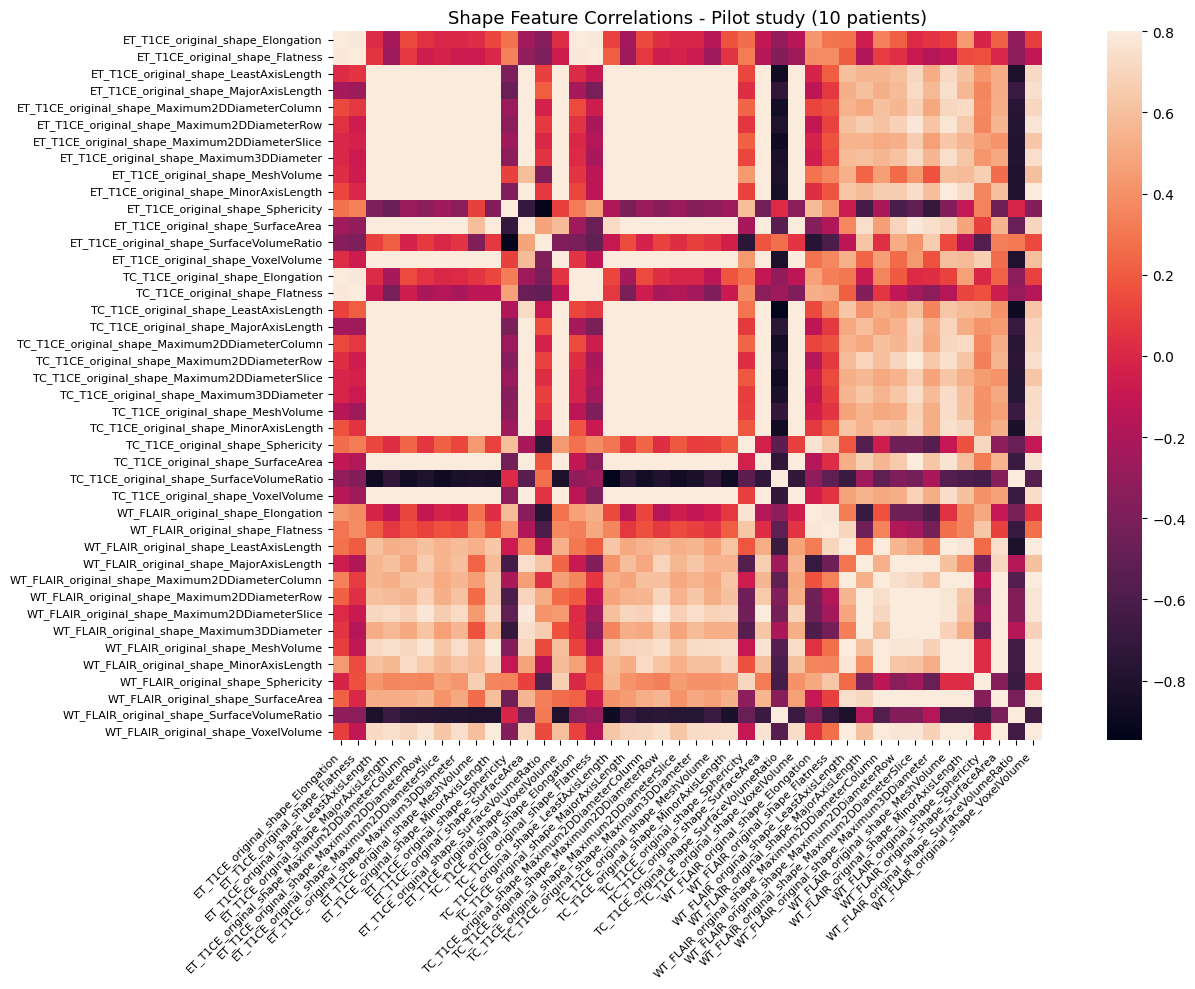

Saved - pilot_shape_heatmap.png


In [18]:
# Correlation heatmap of shape features (pilot, GT).
# Adapted from FeatureVisualizationWithClustering.ipynb's heatmap.

shape_feats_pilot = [c for c in pilot_feature_cols if "shape" in c]
d_pilot = df_pilot_gt[shape_feats_pilot].dropna()
corr_pilot = d_pilot.corr()

f, ax = plt.subplots(figsize=(15, 10))
sns.heatmap(corr_pilot, vmax=0.8, square=True, xticklabels=True, yticklabels=True)
ax.set_title("Shape Feature Correlations - Pilot study (10 patients)", fontsize=13)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "pilot_shape_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved - pilot_shape_heatmap.png")

## 6. Pilot: clustermap

Visualisation using `sns.clustermap` shows hierarchical groupings of correlated features. Applied per region (ET, TC, WT) to the shape features, with constant columns dropped and regions having < 4 usable features skipped. With 10 patients the plots are readable and serve as a redundancy smoke test, not a statistical result.

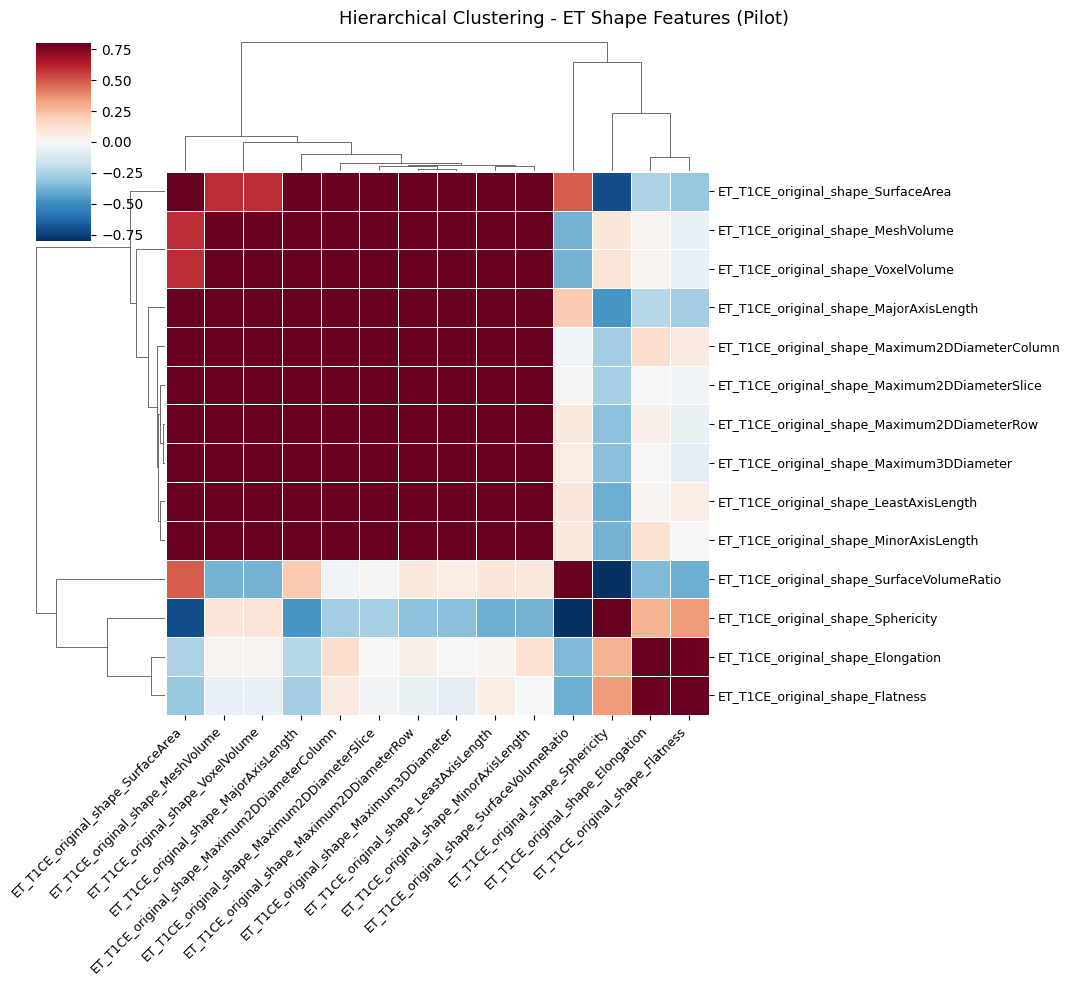

Saved - pilot_clustermap_ET.png.


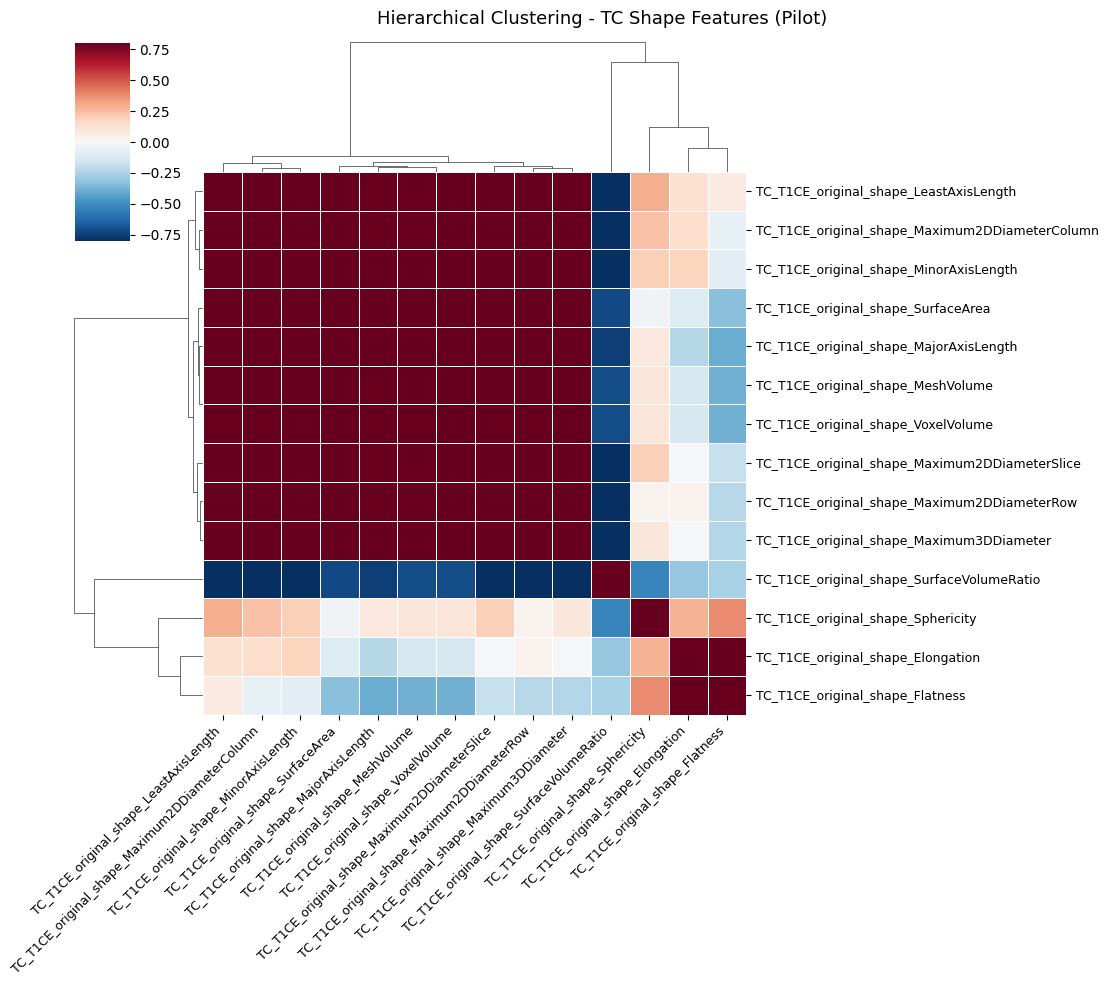

Saved - pilot_clustermap_TC.png.


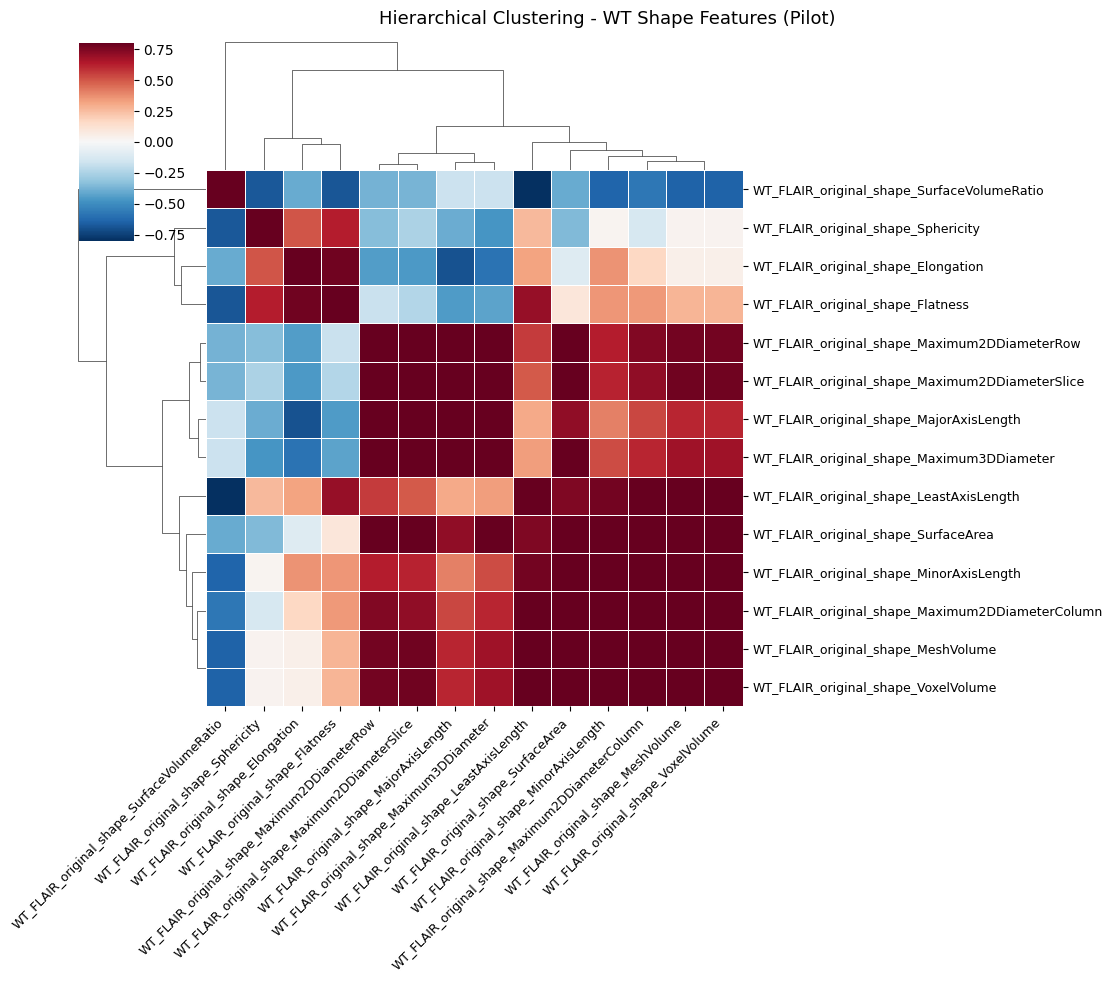

Saved - pilot_clustermap_WT.png.

Pilot study completed. Pipeline confirmed. Proceeding to full extraction.


In [20]:
# Per-region shape-feature redundancy clustermaps (pilot smoke test).
# Adapted from FeatureVisualizationWithClustering.ipynb's clustermap.

for region in ["ET", "TC", "WT"]:
    region_shape = [c for c in df_pilot_gt.columns if c.startswith(f"{region}_") and "shape" in c]
    dd = df_pilot_gt[region_shape].dropna()
    dd = dd.loc[:, dd.std() > 0]

    if dd.shape[1] < 4:
        print(f"{region}: <4 usable shape features - skipping clustermap")
        continue

    pp = sns.clustermap(dd.corr(), linewidths=0.5, figsize=(11, 11), cmap="RdBu_r", vmax=0.8, vmin=-0.8, center=0)
    _ = plt.setp(pp.ax_heatmap.get_yticklabels(), rotation=0, fontsize=9)
    _ = plt.setp(pp.ax_heatmap.get_xticklabels(), rotation=45, ha="right", fontsize=9)
    plt.suptitle(f"Hierarchical Clustering - {region} Shape Features (Pilot)", y=1.01, fontsize=13)
    plt.savefig(os.path.join(output_dir, f"pilot_clustermap_{region}.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved - pilot_clustermap_{region}.png.")

print("\nPilot study completed. Pipeline confirmed. Proceeding to full extraction.")

## Full Extraction

Full radiomic feature extraction on every validation patient that has a Swin-UNETR predicted mask (count reported by the cells below). Ground-truth and predicted features are extracted with the identical loop and the same `GT_LABEL_MAP`.

## 1. Extract features from Ground Truth masks

Extract radiomic features from the ground-truth `*_seg.nii.gz` masks for every patient. GT masks use raw BraTS21 labels (1 = NCR, 2 = ED, 4 = ET), grouped into subregions via `GT_LABEL_MAP`: ET = {4}, TC = {1, 4}, WT = {1, 2, 4}. Each subregion is extracted from its configured modality (ET and TC on T1ce, WT on FLAIR).


In [21]:
# Check predicted mask files for unexpected label values
patient_ids = all_patient_ids
pred_paths = [os.path.join(masks_dir, f"pred_{pid}.nii.gz") for pid in patient_ids]
seen = set()
for p in pred_paths:
    if os.path.exists(p):
        seen.update(np.unique(sitk.GetArrayFromImage(sitk.ReadImage(p))).astype(int).tolist())
print(f"Predicted labels: {sorted(seen)}")
assert seen <= {0, 1, 2, 4}, f"Predicted masks not in expected {{1,2,4}} space: {sorted(seen)}"

Predicted labels: [0, 1, 2, 4]


In [22]:
# Use all patients with predicted masks (paired set for ground truth vs predicted ICC)
print(f"Running full extraction on {len(patient_ids)} patients")

gt_rows = []
gt_skips = []

for i, pid in enumerate(patient_ids):
    print(f"[{i+1}/{len(patient_ids)}] {pid}")
    patient_dir = os.path.join(data_dir, pid)
    row = {"patient_id": pid}

    gt_mask_path = os.path.join(patient_dir, f"{pid}_seg.nii.gz")
    if not os.path.exists(gt_mask_path):
        gt_skips.append({"patient_id": pid, "subregion": None, "reason": "missing GT mask"})
        continue
    raw_mask_sitk = sitk.ReadImage(gt_mask_path)

    for subregion, cfg in SUBREGIONS.items():
        modality = cfg["modality"]
        image_path = os.path.join(patient_dir, f"{pid}{MODALITY_SUFFIX[modality]}")
        if not os.path.exists(image_path):
            gt_skips.append({"patient_id": pid, "subregion": subregion, "reason": f"missing image ({modality})"})
            continue
        mask_sitk = get_binary_mask_sitk(raw_mask_sitk, GT_LABEL_MAP[subregion])
        features = extract_patient_features(extractor, pid, image_path, mask_sitk, subregion, modality)
        if features:
            row.update(features)
        else:
            gt_skips.append({"patient_id": pid, "subregion": subregion, "reason": "no features (small ROI or extraction failed)"})

    if len(row) > 1:
        gt_rows.append(row)
    else:
        gt_skips.append({"patient_id": pid, "subregion": None, "reason": "no features for any subregion"})

# Feature table
df_gt = pd.DataFrame(gt_rows)
gt_path = os.path.join(output_dir, "01_features_gt.csv")
df_gt.to_csv(gt_path, index=False)

# Skip log
df_gt_skips = pd.DataFrame(gt_skips)
skips_path = os.path.join(output_dir, "01_features_gt_skips.csv")
df_gt_skips.to_csv(skips_path, index=False)

# Run summary
print(f"\nGT extraction done: attempted {len(patient_ids)}, "
      f"extracted {df_gt.shape[0]}, logged {len(gt_skips)} skip event(s)")
print(f"Feature matrix: {df_gt.shape[0]} patients × {df_gt.shape[1]} columns "
      f"({int(df_gt.isna().sum().sum())} NaN cells)")
for region in ["ET", "TC", "WT"]:
    region_cols = [c for c in df_gt.columns if c.startswith(f"{region}_")]
    n_valid = int(df_gt[region_cols].notna().any(axis=1).sum()) if region_cols else 0
    print(f"{region}: {n_valid}/{df_gt.shape[0]} patients have features")
print("Saved - 01_features_gt.csv, 01_features_gt_skips.csv.")
df_gt.head()

Running full extraction on 250 patients
[1/250] BraTS2021_00002
[2/250] BraTS2021_00006
[3/250] BraTS2021_00025
[4/250] BraTS2021_00060
[5/250] BraTS2021_00064
[6/250] BraTS2021_00068
[7/250] BraTS2021_00071
[8/250] BraTS2021_00072
[9/250] BraTS2021_00081
[10/250] BraTS2021_00087
[11/250] BraTS2021_00088
[12/250] BraTS2021_00089
[13/250] BraTS2021_00096
[14/250] BraTS2021_00098
[15/250] BraTS2021_00100
[16/250] BraTS2021_00102
[17/250] BraTS2021_00104
[18/250] BraTS2021_00108
[19/250] BraTS2021_00115
[20/250] BraTS2021_00123
[21/250] BraTS2021_00128
[22/250] BraTS2021_00130
[23/250] BraTS2021_00133
[24/250] BraTS2021_00138
[25/250] BraTS2021_00155
[26/250] BraTS2021_00156
[27/250] BraTS2021_00166
[28/250] BraTS2021_00167
[29/250] BraTS2021_00171
[30/250] BraTS2021_00177
[31/250] BraTS2021_00178
[32/250] BraTS2021_00212
[33/250] BraTS2021_00217
[34/250] BraTS2021_00218
[35/250] BraTS2021_00219
[36/250] BraTS2021_00236
[37/250] BraTS2021_00238
[38/250] BraTS2021_00261
[39/250] BraTS2021_

,patient_id,ET_T1CE_original_shape_Elongation,ET_T1CE_original_shape_Flatness,ET_T1CE_original_shape_LeastAxisLength,ET_T1CE_original_shape_MajorAxisLength,ET_T1CE_original_shape_Maximum2DDiameterColumn,ET_T1CE_original_shape_Maximum2DDiameterRow,ET_T1CE_original_shape_Maximum2DDiameterSlice,ET_T1CE_original_shape_Maximum3DDiameter,ET_T1CE_original_shape_MeshVolume,...,WT_FLAIR_original_gldm_GrayLevelNonUniformity,WT_FLAIR_original_gldm_GrayLevelVariance,WT_FLAIR_original_gldm_HighGrayLevelEmphasis,WT_FLAIR_original_gldm_LargeDependenceEmphasis,WT_FLAIR_original_gldm_LargeDependenceHighGrayLevelEmphasis,WT_FLAIR_original_gldm_LargeDependenceLowGrayLevelEmphasis,WT_FLAIR_original_gldm_LowGrayLevelEmphasis,WT_FLAIR_original_gldm_SmallDependenceEmphasis,WT_FLAIR_original_gldm_SmallDependenceHighGrayLevelEmphasis,WT_FLAIR_original_gldm_SmallDependenceLowGrayLevelEmphasis
0,BraTS2021_00002,0.790423,0.669309,33.947668,50.720477,45.617979,51.971146,48.301139,53.749419,23713.041667,...,5163.158815,159.834816,2645.909009,37.184132,89507.443832,0.018680,0.000501,0.161382,449.962646,0.000101
1,BraTS2021_00006,0.731321,0.604173,33.053718,54.709023,45.694639,60.033324,61.400326,61.911227,51902.333333,...,2035.350395,378.849761,7497.400165,13.022521,113249.918826,0.001751,0.000185,0.339196,2164.615053,0.000083
2,BraTS2021_00025,0.648505,0.536265,15.669208,29.219171,28.600699,28.844410,23.259407,30.935417,5144.083333,...,768.357573,123.908537,5774.316795,12.512109,82382.089213,0.002108,0.000228,0.316851,1663.590960,0.000104
3,BraTS2021_00060,0.746911,0.580845,46.186599,79.516219,62.649820,81.344945,76.687678,84.888162,61848.791667,...,3148.220541,477.072197,7095.413162,10.398630,86208.293132,0.001917,0.000289,0.371990,2319.409221,0.000146
4,BraTS2021_00064,0.727334,0.649927,36.906894,56.786195,47.381431,62.513998,62.968246,63.166447,25861.041667,...,1771.458492,288.307904,5456.252538,9.292893,58437.084712,0.001880,0.000264,0.398484,1968.592562,0.000128


In [23]:
# Did the masks get cleaned during extraction? Spot-check one patient's ET.
pid = df_gt["patient_id"].iloc[0]
import SimpleITK as sitk
raw = sitk.GetArrayFromImage(sitk.ReadImage(os.path.join(masks_dir, f"pred_{pid}.nii.gz")))
binary = np.isin(raw, GT_LABEL_MAP["ET"]).astype(np.uint8)
cleaned = sitk.GetArrayFromImage(get_binary_mask_sitk(sitk.ReadImage(os.path.join(masks_dir, f"pred_{pid}.nii.gz")), GT_LABEL_MAP["ET"]))
from scipy import ndimage
print("raw ET components:", ndimage.label(binary)[1])
print("cleaned ET components:", ndimage.label(cleaned)[1], "(should be 1 if cleaning is active)")

raw ET components: 5
cleaned ET components: 1 (should be 1 if cleaning is active)


## 2. Extract features from Predicted masks

The identical extraction loop as the ground-truth step above, applied to the Swin-UNETR predicted masks (`pred_<patient_id>.nii.gz`). Predicted masks are expected to use the same {1, 2, 4} BraTS encoding as the GT (enhancing tumour written as 4), so the same `GT_LABEL_MAP` applies. This is verified at runtime by the label-space check in the cell below (it warns if label 4 is absent or an unexpected label appears).

In [24]:
pred_rows = []
pred_skips = []
pred_labels_seen = set()   # confirm that predicted masks use the {1,2,4} BraTS encoding

for i, pid in enumerate(patient_ids):
    print(f"[{i+1}/{len(patient_ids)}] {pid}")
    patient_dir = os.path.join(data_dir, pid)
    row = {"patient_id": pid}

    pred_mask_path = os.path.join(masks_dir, f"pred_{pid}.nii.gz")
    if not os.path.exists(pred_mask_path):
        pred_skips.append({"patient_id": pid, "subregion": None, "reason": "missing predicted mask"})
        continue
    raw_mask_sitk = sitk.ReadImage(pred_mask_path)
    pred_labels_seen.update(np.unique(sitk.GetArrayFromImage(raw_mask_sitk)).astype(int).tolist())

    for subregion, cfg in SUBREGIONS.items():
        modality = cfg["modality"]
        image_path = os.path.join(patient_dir, f"{pid}{MODALITY_SUFFIX[modality]}")
        if not os.path.exists(image_path):
            pred_skips.append({"patient_id": pid, "subregion": subregion, "reason": f"missing image ({modality})"})
            continue
        mask_sitk = get_binary_mask_sitk(raw_mask_sitk, GT_LABEL_MAP[subregion])
        features = extract_patient_features(extractor, pid, image_path, mask_sitk, subregion, modality)
        if features:
            row.update(features)
        else:
            pred_skips.append({"patient_id": pid, "subregion": subregion, "reason": "no features (small ROI or extraction failed)"})

    if len(row) > 1:
        pred_rows.append(row)
    else:
        pred_skips.append({"patient_id": pid, "subregion": None, "reason": "no features for any subregion"})

# Feature table
df_pred = pd.DataFrame(pred_rows)
pred_path = os.path.join(output_dir, "01_features_predicted.csv")
df_pred.to_csv(pred_path, index=False)

# Skip log
df_pred_skips = pd.DataFrame(pred_skips)
pred_skips_path = os.path.join(output_dir, "01_features_predicted_skips.csv")
df_pred_skips.to_csv(pred_skips_path, index=False)

# Label sanity check - GT_LABEL_MAP assumes {1,2,4}
print(f"\nPredicted mask labels seen across cohort: {sorted(pred_labels_seen)}")
if not pred_labels_seen <= {0, 1, 2, 4}:
    print("Unexpected label(s) - GT_LABEL_MAP {1,2,4} may not match the predicted masks!")
if 4 not in pred_labels_seen:
    print("Label 4 (ET) never appears - predicted masks may encode ET differently (e.g. 3).")

# Run summary
print(f"\nPredicted extraction done: attempted {len(patient_ids)}, "
      f"extracted {df_pred.shape[0]}, logged {len(pred_skips)} skip event(s)")
print(f"Feature matrix: {df_pred.shape[0]} patients × {df_pred.shape[1]} columns "
      f"({int(df_pred.isna().sum().sum())} NaN cells)")
for region in ["ET", "TC", "WT"]:
    region_cols = [c for c in df_pred.columns if c.startswith(f"{region}_")]
    n_valid = int(df_pred[region_cols].notna().any(axis=1).sum()) if region_cols else 0
    print(f"{region}: {n_valid}/{df_pred.shape[0]} patients have features")
print("Saved - 01_features_predicted.csv, 01_features_predicted_skips.csv.")
df_pred.head()

[1/250] BraTS2021_00002
[2/250] BraTS2021_00006
[3/250] BraTS2021_00025
[4/250] BraTS2021_00060
[5/250] BraTS2021_00064
[6/250] BraTS2021_00068
[7/250] BraTS2021_00071
[8/250] BraTS2021_00072
[9/250] BraTS2021_00081
[10/250] BraTS2021_00087
[11/250] BraTS2021_00088
[12/250] BraTS2021_00089
[13/250] BraTS2021_00096
[14/250] BraTS2021_00098
[15/250] BraTS2021_00100
[16/250] BraTS2021_00102
[17/250] BraTS2021_00104
[18/250] BraTS2021_00108
[19/250] BraTS2021_00115
[20/250] BraTS2021_00123
[21/250] BraTS2021_00128
[22/250] BraTS2021_00130
[23/250] BraTS2021_00133
[24/250] BraTS2021_00138
[25/250] BraTS2021_00155
[26/250] BraTS2021_00156
[27/250] BraTS2021_00166
[28/250] BraTS2021_00167
[29/250] BraTS2021_00171
[30/250] BraTS2021_00177
[31/250] BraTS2021_00178
[32/250] BraTS2021_00212
[33/250] BraTS2021_00217
[34/250] BraTS2021_00218
[35/250] BraTS2021_00219
[36/250] BraTS2021_00236
[37/250] BraTS2021_00238
[38/250] BraTS2021_00261
[39/250] BraTS2021_00262
[40/250] BraTS2021_00263
[41/250] 

,patient_id,ET_T1CE_original_shape_Elongation,ET_T1CE_original_shape_Flatness,ET_T1CE_original_shape_LeastAxisLength,ET_T1CE_original_shape_MajorAxisLength,ET_T1CE_original_shape_Maximum2DDiameterColumn,ET_T1CE_original_shape_Maximum2DDiameterRow,ET_T1CE_original_shape_Maximum2DDiameterSlice,ET_T1CE_original_shape_Maximum3DDiameter,ET_T1CE_original_shape_MeshVolume,...,WT_FLAIR_original_gldm_GrayLevelNonUniformity,WT_FLAIR_original_gldm_GrayLevelVariance,WT_FLAIR_original_gldm_HighGrayLevelEmphasis,WT_FLAIR_original_gldm_LargeDependenceEmphasis,WT_FLAIR_original_gldm_LargeDependenceHighGrayLevelEmphasis,WT_FLAIR_original_gldm_LargeDependenceLowGrayLevelEmphasis,WT_FLAIR_original_gldm_LowGrayLevelEmphasis,WT_FLAIR_original_gldm_SmallDependenceEmphasis,WT_FLAIR_original_gldm_SmallDependenceHighGrayLevelEmphasis,WT_FLAIR_original_gldm_SmallDependenceLowGrayLevelEmphasis
0,BraTS2021_00002,0.808039,0.696540,33.402342,47.954631,44.777226,50.695167,47.759816,52.096065,20179.916667,...,4369.042638,136.934790,1792.553460,33.757626,54995.079730,0.027301,0.000754,0.164874,321.352239,0.000123
1,BraTS2021_00006,0.726242,0.595203,32.922386,55.312912,46.141088,60.299254,61.660360,62.880840,52298.625000,...,2027.407834,388.226470,12493.144974,13.002676,183304.642068,0.001280,0.000150,0.337216,3721.381309,0.000064
2,BraTS2021_00025,0.550298,0.434590,13.312247,30.631748,28.460499,27.166155,20.591260,29.478806,3891.750000,...,520.959141,111.309145,3911.627087,14.554537,65754.064378,0.003670,0.000344,0.278455,978.568781,0.000145
3,BraTS2021_00060,0.744622,0.561900,45.252963,80.535552,63.780875,83.096330,76.105190,83.642095,64542.291667,...,3262.337869,475.508448,7405.924586,10.342485,89221.578810,0.001648,0.000222,0.372501,2434.879198,0.000107
4,BraTS2021_00064,0.735378,0.658961,36.436340,55.293629,47.095647,59.135438,60.530984,61.204575,23870.875000,...,1801.622034,394.742102,5945.275506,10.113900,63151.027505,0.027182,0.000854,0.387851,2145.895387,0.000173


## 3. Exclusion summary

Read the skip logs written during the full GT and predicted extraction and tabulate, per subregion, how many patient/subregion extractions were dropped (missing file, ROI too small, or extraction failure).

In [26]:
# tabulate extraction exclusions per subregion from the skip logs
for tag, skips_csv in [("Ground truth", "01_features_gt_skips.csv"),
                       ("Predicted",    "01_features_predicted_skips.csv")]:
    path = os.path.join(output_dir, skips_csv)
    if not os.path.exists(path):
        print(f"{tag}: {skips_csv} not found (run the extraction cell first).")
        continue
    df_sk = pd.read_csv(path)
    print(f"\n{tag}: {len(df_sk)} skip event(s) logged")
    if len(df_sk) == 0:
        print("  No patients excluded.")
        continue
    # whole-patient skips (subregion is NaN) vs per-subregion skips
    per_region = df_sk[df_sk["subregion"].notna()]
    whole = df_sk[df_sk["subregion"].isna()]
    if len(per_region):
        print("  Per-subregion exclusions:")
        for (region, reason), n in per_region.groupby(["subregion", "reason"]).size().items():
            print(f"    {region:<3} | {reason:<40} | {n}")
    if len(whole):
        print("  Whole-patient exclusions:")
        for reason, n in whole.groupby("reason").size().items():
            print(f"    ALL | {reason:<40} | {n}")


Ground truth: 9 skip event(s) logged
  Per-subregion exclusions:
    ET  | no features (small ROI or extraction failed) | 7
    TC  | no features (small ROI or extraction failed) | 2

Predicted: 2 skip event(s) logged
  Per-subregion exclusions:
    ET  | no features (small ROI or extraction failed) | 1
    TC  | no features (small ROI or extraction failed) | 1


## 4. Feature overview

Pre-ICC alignment and inventory: confirm the GT and predicted tables share the same patients and the same feature columns, then report per-region feature counts and missing-value structure. The final block reports, per subregion, how many patients have the region present in **both** masks - the effective sample size each ICC is computed on.

In [28]:
# Confirm GT and predicted are aligned before ICC: same patients and same feature columns
print("Same patients:", set(df_gt["patient_id"]) == set(df_pred["patient_id"]))
print("Same columns:", set(df_gt.columns) == set(df_pred.columns))

def feature_inventory(df, name):
    feature_cols = [c for c in df.columns if c.startswith(("ET_", "TC_", "WT_"))]
    print(f"\n{name}: {df.shape[0]} patients × {df.shape[1]} columns, {len(feature_cols)} features")
    for region in ["ET", "TC", "WT"]:
        cols = [c for c in feature_cols if c.startswith(f"{region}_")]
        if not cols:
            continue
        present = int(df[cols].notna().any(axis=1).sum())   # patients who have the region
        missing_region = df.shape[0] - present              # patients missing the whole region
        scattered = int(df.loc[df[cols].notna().any(axis=1), cols].isna().sum().sum())  # NaNs among present
        print(f"  {region}: {len(cols)} features | {present} present, {missing_region} missing region, {scattered} scattered NaN")

feature_inventory(df_gt, "Ground Truth")
feature_inventory(df_pred, "Predicted")

gt_i, pred_i = df_gt.set_index("patient_id"), df_pred.set_index("patient_id")
common = gt_i.index.intersection(pred_i.index)
for region in ["ET", "TC", "WT"]:
    cols = [c for c in df_gt.columns if c.startswith(f"{region}_")]
    if not cols:
        continue
    both = (gt_i.loc[common, cols].notna().any(axis=1) &
            pred_i.loc[common, cols].notna().any(axis=1)).sum()
    print(f"{region}: {int(both)}/{len(common)} present in BOTH (effective ICC n)")

Same patients: True
Same columns: True

Ground Truth: 250 patients × 301 columns, 300 features
  ET: 100 features | 243 present, 7 missing region, 0 scattered NaN
  TC: 100 features | 248 present, 2 missing region, 0 scattered NaN
  WT: 100 features | 250 present, 0 missing region, 0 scattered NaN

Predicted: 250 patients × 301 columns, 300 features
  ET: 100 features | 249 present, 1 missing region, 0 scattered NaN
  TC: 100 features | 249 present, 1 missing region, 0 scattered NaN
  WT: 100 features | 250 present, 0 missing region, 0 scattered NaN
ET: 243/250 present in BOTH (effective ICC n)
TC: 247/250 present in BOTH (effective ICC n)
WT: 250/250 present in BOTH (effective ICC n)


## 5. Feature selection

## 5.1 ICC stability filter
The intraclass correlation coefficient (ICC) measures how consistent each feature is between the ground-truth and predicted masks. Treating the GT and predicted segmentations as two "raters" of the same patients, a high ICC means the feature value barely changes when the mask changes - i.e. it is robust to segmentation error and safe to use downstream, where only predicted masks are available.

Interpretation bands (applied to the ICC point estimate, for labelling only):
- **ICC > 0.90** - excellent
- **0.75 < ICC <= 0.90** - good
- **0.50 < ICC <= 0.75** - moderate
- **ICC <= 0.50** - poor

The **keep / drop decision is separate** from these labels: a feature is kept when the **95% CI lower bound of ICC(2,1) exceeds 0.75** (a conservative criterion). ICC(2,1) is two-way random effects, absolute agreement - the standard in radiomics reliability studies.

ICC is computed per feature on the patients that have that feature in both masks.

In [29]:
class FeatureStabilityFilter:
    """Per-feature ICC stability filter. """
    def __init__(self, df_data, icc_threshold=ICC_THRESHOLD, use_ci_lower_bound=USE_CI_LOWER_BOUND):
        self.df_data = df_data
        self.icc_threshold = float(icc_threshold)
        self.use_ci_lower_bound = use_ci_lower_bound

    @staticmethod
    def _mean_squares(ratings):
        """Mean squares calculation for ICC."""
        n_subjects, n_raters = ratings.shape
        SStotal = np.var(ratings, ddof=1) * (n_subjects * n_raters - 1)
        MSr = np.var(np.mean(ratings, axis=1), ddof=1) * n_raters
        MSw = np.sum(np.var(ratings, axis=1, ddof=1) / n_subjects)
        MSc = np.var(np.mean(ratings, axis=0), ddof=1) * n_subjects
        MSe = (SStotal - MSr * (n_subjects - 1) - MSc * (n_raters - 1)) / ((n_subjects - 1) * (n_raters - 1))
        return n_subjects, n_raters, MSr, MSw, MSc, MSe

    @staticmethod
    def icc_oneway_icc1(ratings, alpha=0.05):
        """ICC(1,1) - oneway random, absolute agreement, single."""
        n_subjects, n_raters, MSr, MSw, MSc, MSe = FeatureStabilityFilter._mean_squares(ratings)
        coeff = (MSr - MSw) / (MSr + (n_raters - 1) * MSw)
        Fvalue = MSr / MSw
        df1 = n_subjects - 1
        df2 = n_subjects * (n_raters - 1)
        pvalue = 1 - stats.f.cdf(Fvalue, df1, df2)
        FL = Fvalue / stats.f.ppf(1 - alpha / 2, df1, df2)   # two-sided 95% CI
        FU = Fvalue * stats.f.ppf(1 - alpha / 2, df2, df1)
        lbound = (FL - 1) / (FL + (n_raters - 1))
        ubound = (FU - 1) / (FU + (n_raters - 1))
        return coeff, (lbound, ubound), pvalue

    @staticmethod
    def icc_twoway_icc2(ratings, alpha=0.05):
        """ICC(2,1) - twoway random, absolute agreement, single."""
        n_subjects, n_raters, MSr, MSw, MSc, MSe = FeatureStabilityFilter._mean_squares(ratings)
        coeff = (MSr - MSe) / (MSr + (n_raters - 1) * MSe + (n_raters / n_subjects) * (MSc - MSe))
        Fvalue = MSr / MSe
        df1 = n_subjects - 1
        df2 = (n_subjects - 1) * (n_raters - 1)
        pvalue = 1 - stats.f.cdf(Fvalue, df1, df2)
        Fj = MSc / MSe
        vn = (n_raters - 1) * (n_subjects - 1) * (n_raters * coeff * Fj + n_subjects * (1 + (n_raters - 1) * coeff) - n_raters * coeff) ** 2
        vd = (n_subjects - 1) * n_raters ** 2 * coeff ** 2 * Fj ** 2 + (n_subjects * (1 + (n_raters - 1) * coeff) - n_raters * coeff) ** 2
        v = vn / vd
        FL = stats.f.ppf(1 - alpha / 2, n_subjects - 1, v)   # two-sided 95% CI
        FU = stats.f.ppf(1 - alpha / 2, v, n_subjects - 1)
        lbound = (n_subjects * (MSr - FL * MSe)) / (FL * (n_raters * MSc + (n_raters * n_subjects - n_raters - n_subjects) * MSe) + n_subjects * MSr)
        ubound = (n_subjects * (FU * MSr - MSe)) / (n_raters * MSc + (n_raters * n_subjects - n_raters - n_subjects) * MSe + n_subjects * FU * MSr)
        return coeff, (lbound, ubound), pvalue

    def calculate_ICC(self):
        feats = [c for c in self.df_data.columns
                 if c not in ("ID", "Mask_Transformation")]
        rows = []
        for feat in feats:
            sub = self.df_data[["ID", "Mask_Transformation", feat]].copy()
            sub[feat] = pd.to_numeric(sub[feat], errors="coerce")
            sub = sub.dropna(subset=[feat])
            wide = (sub.pivot_table(index="ID", columns="Mask_Transformation", values=feat, aggfunc="mean").dropna(axis=0, how="any"))
            if wide.shape[0] < 10 or wide.shape[1] < 2:
                continue
            X = wide.to_numpy(float)
            if X.std() == 0:
                continue
            i1, _,  _   = self.icc_oneway_icc1(X)
            i2, c2, p2  = self.icc_twoway_icc2(X)
            r = np.corrcoef(X[:, 0], X[:, 1])[0, 1] if min(X.std(0)) > 0 else np.nan
            rows.append({
                "feature": feat,
                "subregion": feat.split("_")[0],
                "ICC": round(i2, 3),
                "ICC1": round(i1, 3),
                "CI0": round(c2[0], 3),
                "CI1": round(c2[1], 3),
                "pval": p2,
                "pearson_r": round(r, 3),
                "n_targets": int(X.shape[0]),
                "n_raters": int(X.shape[1]),
                "interpretation": ("excellent" if i2 > 0.90 else
                                   "good" if i2 > 0.85 else
                                   "moderate" if i2 > 0.50 else "poor"),
            })
        ICC = pd.DataFrame(rows)
        if not ICC.empty:
            crit = ICC["CI0"] if self.use_ci_lower_bound else ICC["ICC"]
            ICC["keep"] = crit > self.icc_threshold
        return ICC

    def filter_for_unstable_feature_class(self, ICC):
        if ICC.empty:
            return ICC
        crit = ICC["CI0"] if self.use_ci_lower_bound else ICC["ICC"]
        return ICC.loc[crit < self.icc_threshold]
    
# Build long frame: GT and prediction as two raters
common_patients = sorted(set(df_pred["patient_id"]) & set(df_gt["patient_id"]))
print(f"Evaluating {len(common_patients)} patients with both predicted and GT features")

_g = (df_gt[df_gt["patient_id"].isin(common_patients)].assign(Mask_Transformation="GT").rename(columns={"patient_id": "ID"}))
_p = (df_pred[df_pred["patient_id"].isin(common_patients)].assign(Mask_Transformation="Pred").rename(columns={"patient_id": "ID"}))
df_long = pd.concat([_g, _p], ignore_index=True)

fsf = FeatureStabilityFilter(df_long, icc_threshold=ICC_THRESHOLD, use_ci_lower_bound=USE_CI_LOWER_BOUND)
df_icc = fsf.calculate_ICC().sort_values("ICC", ascending=False).reset_index(drop=True)
df_icc.to_csv(os.path.join(output_dir, "02_icc_stability.csv"), index=False)

unstable_df = fsf.filter_for_unstable_feature_class(df_icc)
unstable_features = unstable_df["feature"].tolist()
stable_features = df_icc[df_icc["keep"]]["feature"].tolist()

crit_name = "95% CI lower bound" if USE_CI_LOWER_BOUND else "ICC point estimate"
print(f"\nStability filter ({crit_name} > {ICC_THRESHOLD}): kept {len(stable_features)}, dropped {len(unstable_features)}")
print(df_icc["interpretation"].value_counts())

df_gt_stable = df_gt[["patient_id"] + [f for f in stable_features if f in df_gt.columns]]
df_gt_stable.to_csv(os.path.join(output_dir, "02_features_after_icc.csv"), index=False)

print("\nTop 15 by ICC(2,1):")
print(df_icc.head(15)[["feature", "ICC", "CI0", "CI1", "interpretation"]].to_string(index=False))
print("Saved - 02_icc_stability.csv, 02_features_after_icc.csv.")

Evaluating 250 patients with both predicted and GT features

Stability filter (95% CI lower bound > 0.75): kept 274, dropped 26
interpretation
excellent    223
moderate      43
good          27
poor           7
Name: count, dtype: int64

Top 15 by ICC(2,1):
                                          feature   ICC   CI0   CI1 interpretation
                 TC_T1CE_original_firstorder_Mean 1.000 1.000 1.000      excellent
               TC_T1CE_original_firstorder_Median 1.000 0.999 1.000      excellent
             WT_FLAIR_original_firstorder_Maximum 1.000 1.000 1.000      excellent
                WT_FLAIR_original_firstorder_Mean 1.000 1.000 1.000      excellent
              WT_FLAIR_original_firstorder_Median 1.000 1.000 1.000      excellent
        WT_FLAIR_original_firstorder_90Percentile 1.000 1.000 1.000      excellent
     WT_FLAIR_original_firstorder_RootMeanSquared 1.000 1.000 1.000      excellent
      TC_T1CE_original_firstorder_RootMeanSquared 1.000 1.000 1.000      excel

## 5.2 Correlation pruning

Among the ICC-stable features, many are mutually redundant. This step drops one feature from every highly correlated pair, keeping a single representative per correlated group.

The pruning is greedy and order-dependent: a feature is dropped if it correlates above threshold with any feature retained earlier. This is a redundancy criterion, not a relevance one - features are removed for overlapping with another, not for being uninformative. 

In [30]:
d = df_gt[["patient_id"] + stable_features].dropna()
corr_matrix = d[stable_features].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = set()
for col in upper.columns:
    if any(upper[col].dropna() > CORR_THRESHOLD):
        to_drop.add(col)

final_features = [f for f in stable_features if f not in to_drop]
print(f"Stable features after ICC filter: {len(stable_features)}")
print(f"After correlation pruning (|r|>{CORR_THRESHOLD}): {len(final_features)} features (removed {len(to_drop)} redundant)")

df_final = df_gt[["patient_id"] + final_features].dropna()
df_final.to_csv(os.path.join(output_dir, "03_features_after_correlation.csv"), index=False)

print("\nFinal selected features:")
for f in sorted(final_features):
    icc_val = df_icc[df_icc["feature"] == f]["ICC"].values
    icc_str = f"{icc_val[0]:.3f}" if len(icc_val) > 0 else "N/A"
    print(f"{f:<60} ICC={icc_str}")

print(f"\nSaved - 03_features_after_correlation.csv.")

selection_metadata = {
    "selected_radiomic_features": final_features,
    "ratio_features": ["ET_WT_ratio", "ET_TC_ratio", "TC_WT_ratio",
                       "necrosis_fraction"],
    "n_selected": len(final_features),
    "icc_threshold": ICC_THRESHOLD,                # GT-vs-predicted, two-way ICC(2,1)
    "corr_threshold": CORR_THRESHOLD,
    "n_dev_patients": int(df_gt.shape[0]),
}
with open(os.path.join(output_dir, "03_selection_metadata.json"), "w") as f:
    json.dump(selection_metadata, f, indent=2)
print("Saved - 03_selection_metadata.json.")

Stable features after ICC filter: 274
After correlation pruning (|r|>0.8): 36 features (removed 238 redundant)

Final selected features:
ET_T1CE_original_glcm_Imc1                                   ICC=0.861
ET_T1CE_original_glcm_Imc2                                   ICC=0.913
ET_T1CE_original_gldm_GrayLevelNonUniformity                 ICC=0.986
ET_T1CE_original_shape_Elongation                            ICC=0.864
ET_T1CE_original_shape_Flatness                              ICC=0.874
ET_T1CE_original_shape_Sphericity                            ICC=0.815
ET_T1CE_original_shape_SurfaceVolumeRatio                    ICC=0.808
TC_T1CE_original_firstorder_Mean                             ICC=1.000
TC_T1CE_original_firstorder_Skewness                         ICC=0.895
TC_T1CE_original_glcm_ClusterProminence                      ICC=1.000
TC_T1CE_original_glcm_ClusterShade                           ICC=0.995
TC_T1CE_original_glcm_Correlation                            ICC=0.871
TC_T1CE_ori

## 5.3 Texture exclusion

**Criterion: interpretability (not reliability).**

Feature classes that are statistically valid but not clinically interpretable are dropped, keeping only classes a clinician can reason about. Here, texture classes (GLCM, GLRLM, GLSZM, GLDM) are excluded and only `shape` and `firstorder` are kept. The excluded features may be stable but not reportable. Which classes count as "interpretable" is a project choice set by `INTERPRETABLE_CLASSES`.

In [32]:
# Texture classes are robust but not clinically interpretable -> excluded from the rule engine.

def feature_class(name):
    """Class from a name like ET_T1CE_original_shape_Sphericity -> 'shape'."""
    return name.split("_original_")[1].split("_")[0] if "_original_" in name else "unknown"

interpretable_features = [f for f in final_features if feature_class(f) in INTERPRETABLE_CLASSES]
texture_features = [f for f in final_features if feature_class(f) not in INTERPRETABLE_CLASSES]

by_class = defaultdict(list)
for f in final_features:
    by_class[feature_class(f)].append(f)

print(f"Survivors after ICC and correlation pruning: {len(final_features)}")
for cls in sorted(by_class):
    tag = "interpretable" if cls in INTERPRETABLE_CLASSES else "texture (excluded)"
    print(f"  {cls:<12} {len(by_class[cls]):>2}  [{tag}]")

print(f"\nInterpretable subset for the rule engine: {len(interpretable_features)}")
for f in sorted(interpretable_features):
    print(f"  {f}")

with open(os.path.join(output_dir, "interpretable_features.json"), "w") as fh:
    json.dump({
        "interpretable_features": interpretable_features,
        "interpretable_classes": sorted(INTERPRETABLE_CLASSES),
        "excluded_texture_features": texture_features,
        "n_interpretable": len(interpretable_features),
    }, fh, indent=2)
print(f"\nSaved - interpretable_features.json ({len(interpretable_features)} features)")

Survivors after ICC and correlation pruning: 36
  firstorder    4  [interpretable]
  glcm         12  [texture (excluded)]
  gldm          3  [texture (excluded)]
  glrlm         4  [texture (excluded)]
  glszm         4  [texture (excluded)]
  shape         9  [interpretable]

Interpretable subset for the rule engine: 13
  ET_T1CE_original_shape_Elongation
  ET_T1CE_original_shape_Flatness
  ET_T1CE_original_shape_Sphericity
  ET_T1CE_original_shape_SurfaceVolumeRatio
  TC_T1CE_original_firstorder_Mean
  TC_T1CE_original_firstorder_Skewness
  TC_T1CE_original_shape_SurfaceVolumeRatio
  WT_FLAIR_original_firstorder_Maximum
  WT_FLAIR_original_firstorder_Skewness
  WT_FLAIR_original_shape_Elongation
  WT_FLAIR_original_shape_Flatness
  WT_FLAIR_original_shape_SurfaceVolumeRatio
  WT_FLAIR_original_shape_VoxelVolume

Saved - interpretable_features.json (13 features)


## Visualise: ICC of final features

Horizontal bar plot of the final selected features with their ICC(2,1) point estimates and 95% confidence intervals with the retention threshold marked.

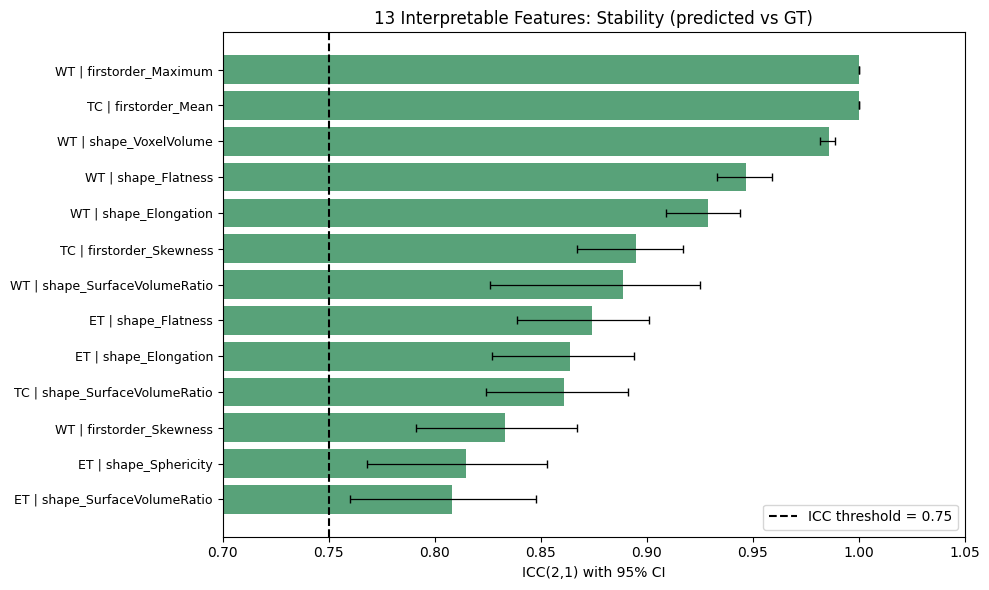

Saved - interpretable_features_icc.png.


In [33]:
viz_features = interpretable_features          # shape + firstorder survivors only
final_icc = df_icc[df_icc["feature"].isin(viz_features)].sort_values("ICC", ascending=True)

fig, ax = plt.subplots(figsize=(10, max(6, len(final_icc) * 0.35)))
ax.barh(range(len(final_icc)), final_icc["ICC"], color="seagreen", alpha=0.8)
ax.errorbar(final_icc["ICC"], range(len(final_icc)),
            xerr=[final_icc["ICC"] - final_icc["CI0"], final_icc["CI1"] - final_icc["ICC"]],
            fmt="none", ecolor="black", elinewidth=0.9, capsize=3)

ax.axvline(x=ICC_THRESHOLD, color="black", linestyle="--", linewidth=1.5,
           label=f"ICC threshold = {ICC_THRESHOLD}")
ax.set_yticks(range(len(final_icc)))
ax.set_yticklabels([f.replace("_T1CE_original_", " | ").replace("_FLAIR_original_", " | ")
                    for f in final_icc["feature"]], fontsize=9)
ax.set_xlabel("ICC(2,1) with 95% CI")
ax.set_title(f"{len(final_icc)} Interpretable Features: Stability (predicted vs GT)", fontsize=12)
ax.legend()
ax.set_xlim(0.7, 1.05)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "interpretable_features_icc.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved - interpretable_features_icc.png.")

## Visualise: GT vs predicted agreement of final features

The ICC filter retains features that are *consistent* between ground-truth and predicted masks, but ICC is a single summary number. Here the agreement is shown directly: for each final interpretable feature, a Bland-Altman plot of the per-patient difference (predicted - GT) against their mean with the mean bias and 95% limits of agreement. This measures the gap between features computed from the ground-truth masks and those computed from the predicted masks.

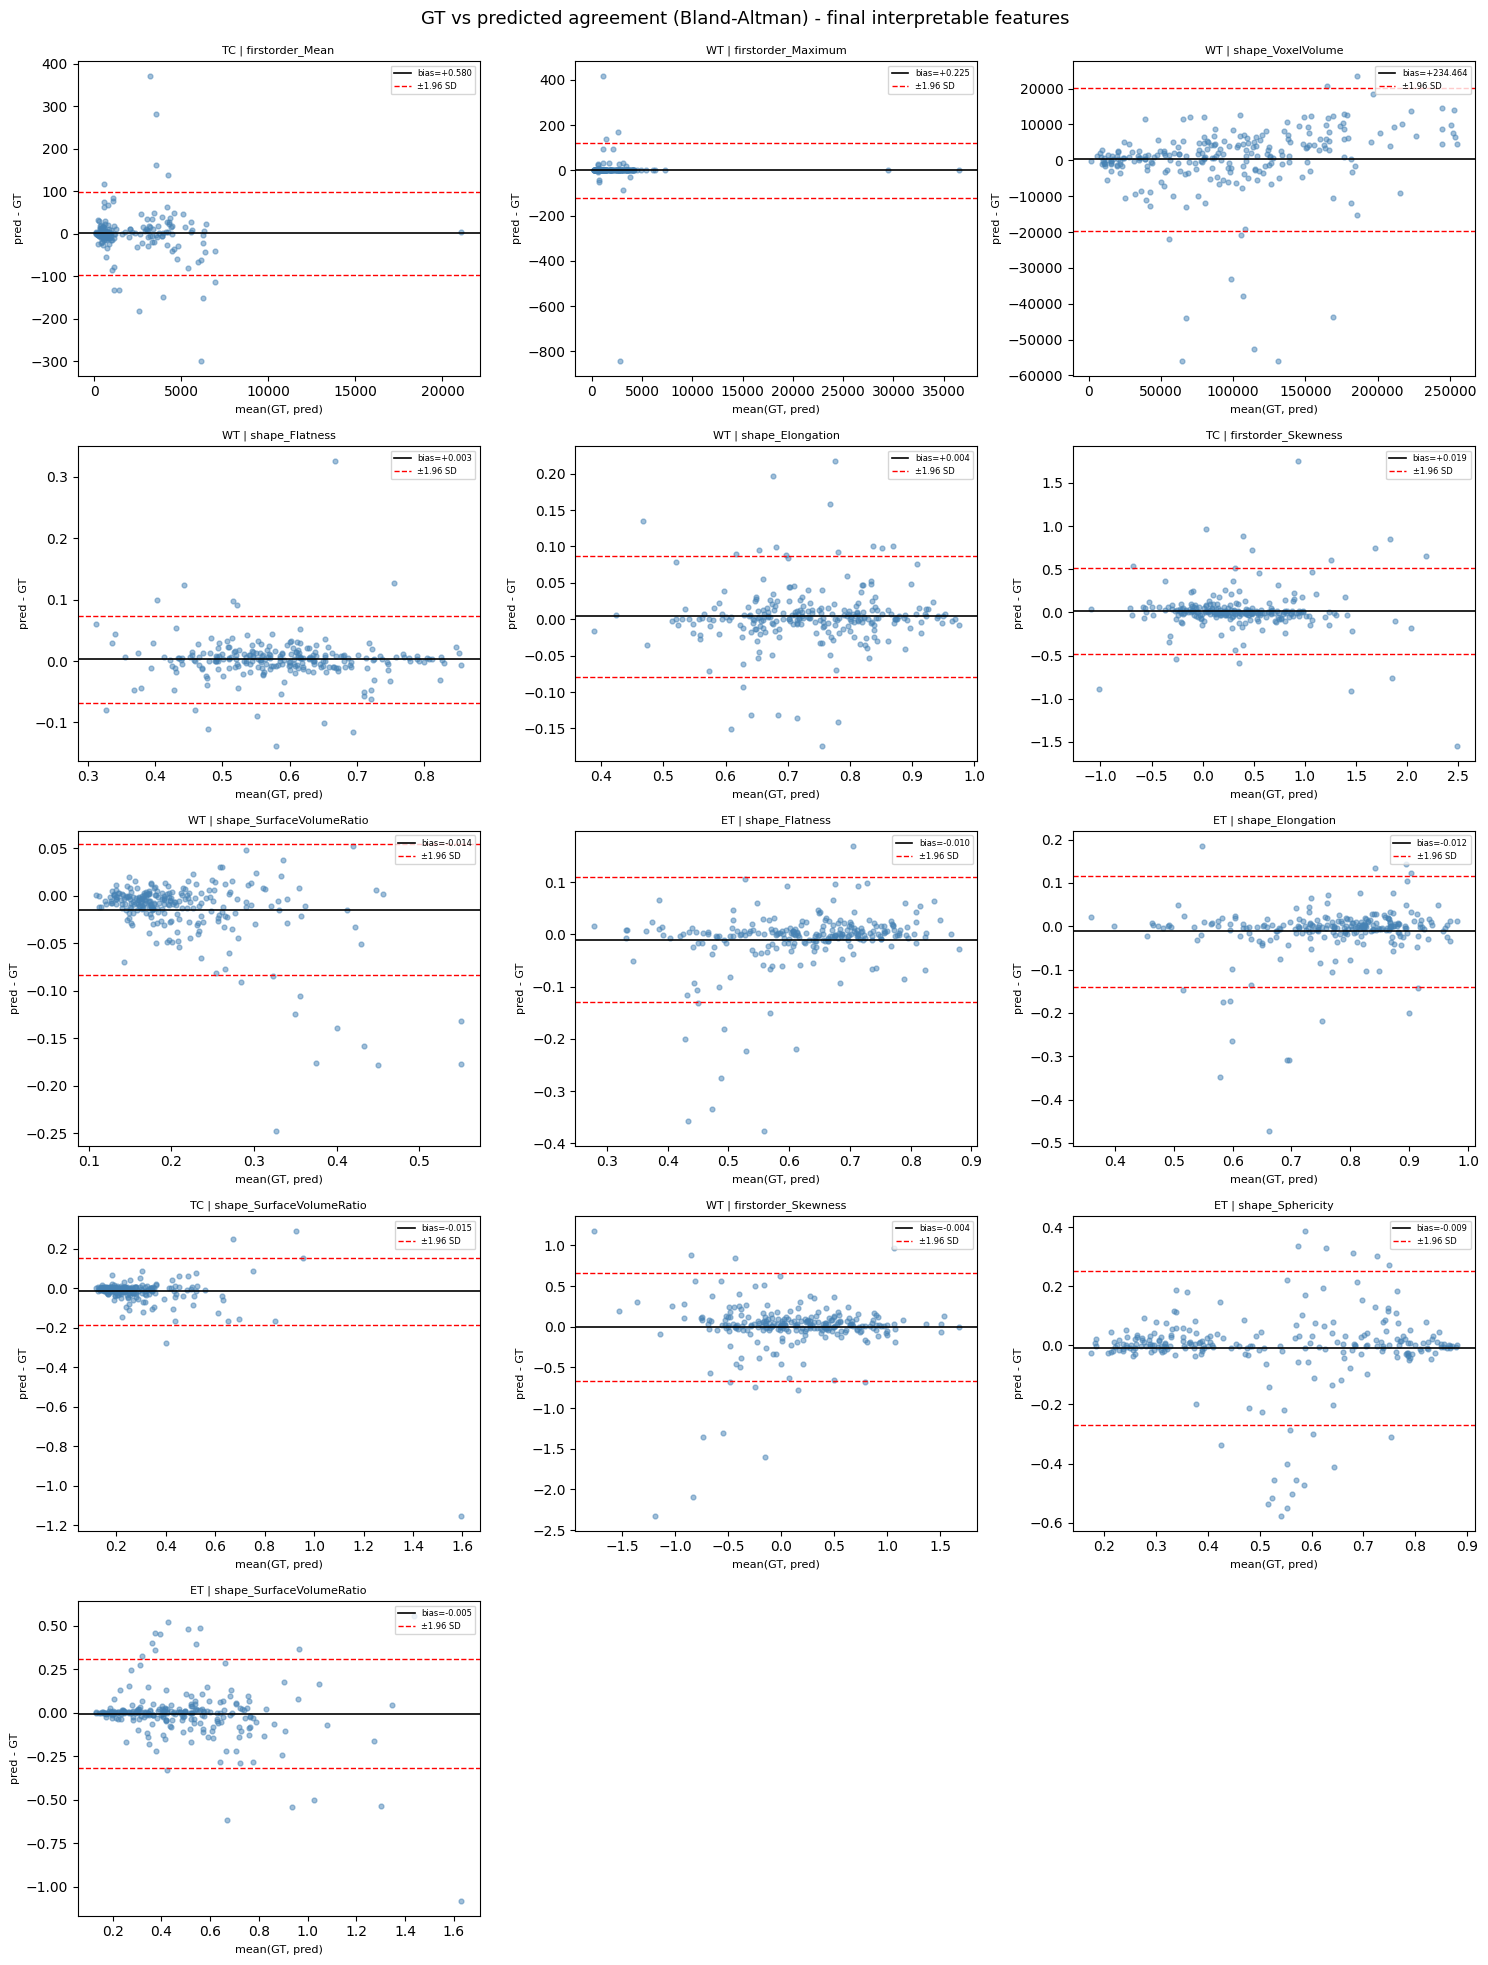

Per-feature GT vs predicted agreement (sorted by mean absolute difference):
                                   feature  n_paired    bias  loa_lower  loa_upper  mean_abs_diff
       WT_FLAIR_original_shape_VoxelVolume       250 234.464 -19743.751  20212.679       5951.432
          TC_T1CE_original_firstorder_Mean       247   0.580    -96.521     97.681         21.008
      WT_FLAIR_original_firstorder_Maximum       250   0.225   -122.347    122.797          8.737
     WT_FLAIR_original_firstorder_Skewness       250  -0.004     -0.672      0.664          0.167
      TC_T1CE_original_firstorder_Skewness       247   0.019     -0.479      0.517          0.116
 ET_T1CE_original_shape_SurfaceVolumeRatio       243  -0.005     -0.316      0.306          0.080
         ET_T1CE_original_shape_Sphericity       243  -0.009     -0.270      0.253          0.068
         ET_T1CE_original_shape_Elongation       243  -0.012     -0.141      0.117          0.031
           ET_T1CE_original_shape_Flatness

In [34]:
def short_name(f):
    return (f.replace("_T1CE_original_", " | ").replace("_FLAIR_original_", " | ")
             .replace("_T1ce_original_", " | "))

agree_feats = interpretable_features
ncols = 3
nrows = int(np.ceil(len(agree_feats) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = np.atleast_1d(axes).ravel()

agreement_rows = []
for ax, feat in zip(axes, agree_feats):
    # pair GT and predicted values per patient; drop patients missing the feature in either mask
    paired = df_gt[["patient_id", feat]].merge(
        df_pred[["patient_id", feat]], on="patient_id", suffixes=("_gt", "_pred")
    ).dropna()
    if len(paired) < 3:
        ax.set_title(short_name(feat) + " (n<3)", fontsize=8); ax.axis("off"); continue
    gt, pred = paired[f"{feat}_gt"].to_numpy(), paired[f"{feat}_pred"].to_numpy()

    diff = pred - gt
    bias = float(np.mean(diff))
    loa = 1.96 * float(np.std(diff, ddof=1))   # 95% limits of agreement
    mean_xy = (gt + pred) / 2

    ax.scatter(mean_xy, diff, s=12, alpha=0.5, color="steelblue")
    ax.axhline(bias, color="black", lw=1.2, label=f"bias={bias:+.3f}")
    ax.axhline(bias + loa, color="red", ls="--", lw=1.0, label="±1.96 SD")
    ax.axhline(bias - loa, color="red", ls="--", lw=1.0)
    ax.set_title(short_name(feat), fontsize=8)
    ax.set_xlabel("mean(GT, pred)", fontsize=8)
    ax.set_ylabel("pred - GT", fontsize=8)
    ax.legend(fontsize=6, loc="upper right")

    agreement_rows.append({
        "feature": feat, "n_paired": len(paired),
        "bias": bias, "loa_lower": bias - loa, "loa_upper": bias + loa,
        "mean_abs_diff": float(np.mean(np.abs(diff))),
    })

for ax in axes[len(agree_feats):]:
    ax.axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.suptitle("GT vs predicted agreement (Bland-Altman) - final interpretable features", fontsize=13)
plt.savefig(os.path.join(output_dir, "interpretable_features_gt_vs_pred_agreement.png"),
            dpi=150, bbox_inches="tight")
plt.show()

df_agreement = pd.DataFrame(agreement_rows).sort_values("mean_abs_diff", ascending=False)
df_agreement.to_csv(os.path.join(output_dir, "supp_agreement_gt_vs_pred.csv"), index=False)
print("Per-feature GT vs predicted agreement (sorted by mean absolute difference):")
print(df_agreement.round(3).to_string(index=False))
print("\nSaved - interpretable_features_gt_vs_pred_agreement.png, supp_agreement_gt_vs_pred.csv.")

## Visualise - correlation heatmap of final features

Correlation matrix of the final selected features.

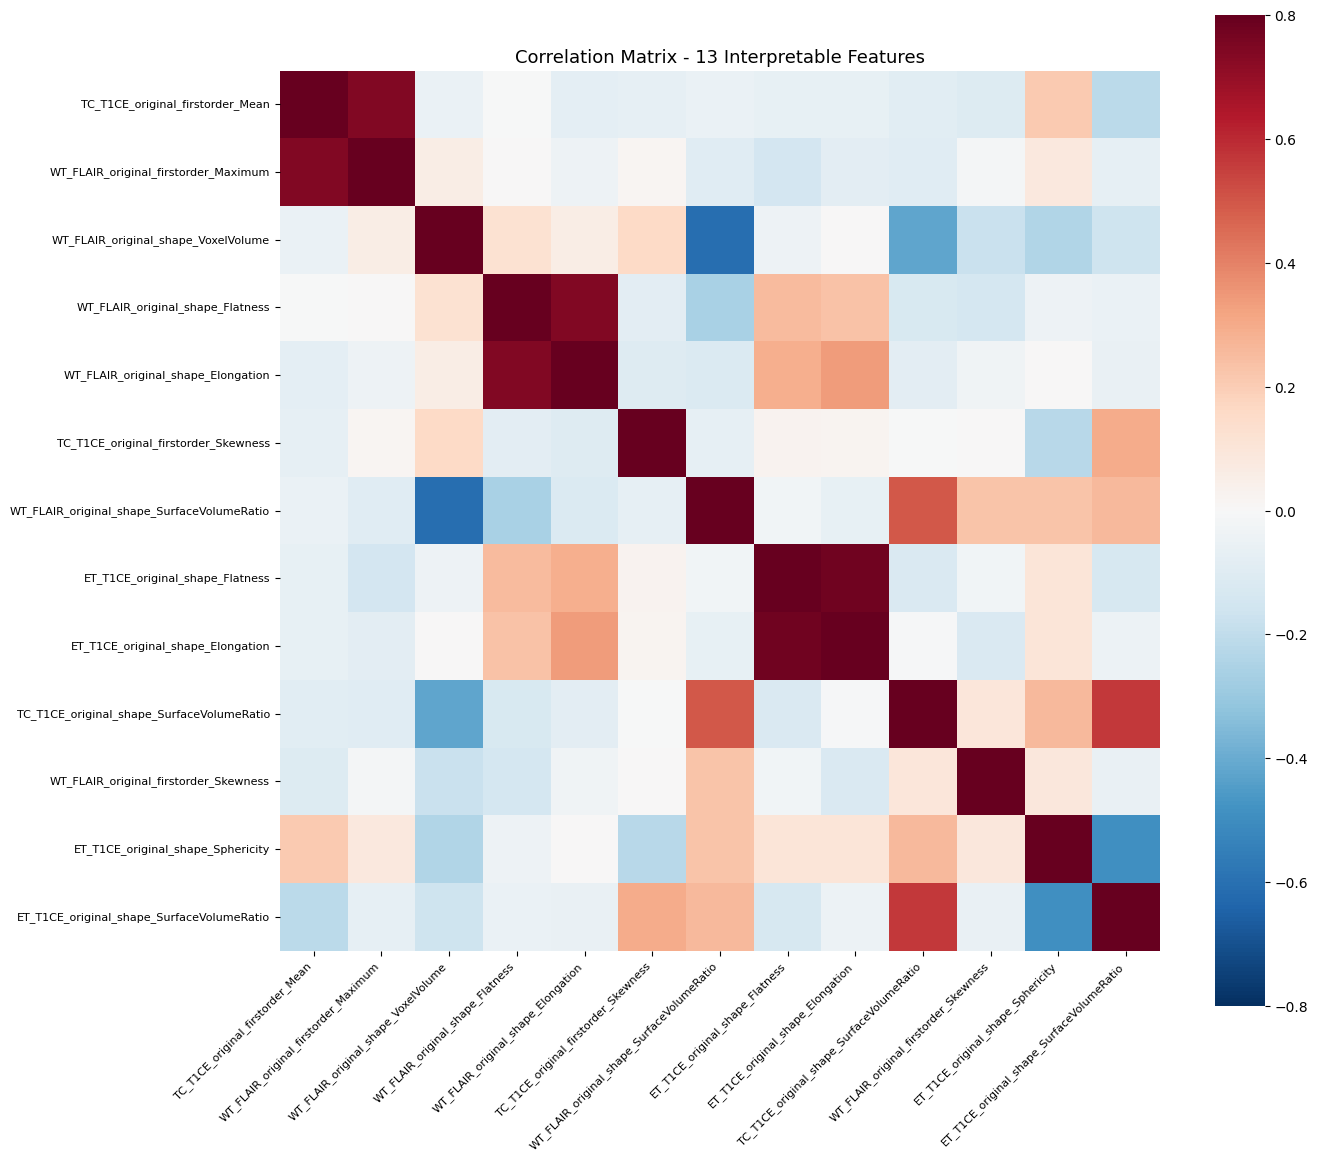

Saved - interpretable_features_correlation.png.


In [35]:
viz_features = interpretable_features          # shape + firstorder survivors only
d_final = df_gt[viz_features].dropna()
corr_final = d_final.corr()

f, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_final, vmax=0.8, vmin=-0.8, center=0, cmap="RdBu_r", square=True,
            xticklabels=True, yticklabels=True, annot=False)
ax.set_title(f"Correlation Matrix - {len(viz_features)} Interpretable Features", fontsize=13)

plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "interpretable_features_correlation.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved - interpretable_features_correlation.png.")

## 6. Derived features

## 6.1 Volumetric ratios

Subregion volume ratios derived from the shape `VoxelVolume` features. Being dimensionless, they are far more scanner-robust than absolute-intensity features:

- **ET/WT**: fraction of the whole tumour that is actively enhancing (small = extensive edema).
- **ET/TC**: fraction of the tumour core that is enhancing (large = substantial active component).
- **TC/WT**: fraction of the whole tumour that is core.
- **necrosis_fraction** = (TC − ET) / TC: necrotic / non-enhancing share of the tumour core.
- **edema_index** = (WT − TC) / TC: edema volume relative to the tumour core.

In [ ]:
et_vol = "ET_T1CE_original_shape_VoxelVolume"
tc_vol = "TC_T1CE_original_shape_VoxelVolume"
wt_vol = "WT_FLAIR_original_shape_VoxelVolume"

if all(c in df_gt.columns for c in [et_vol, tc_vol, wt_vol]):
    cleaned = {}
    for name, df in (("GT", df_gt), ("Pred", df_pred)):
        df["ET_WT_ratio"] = df[et_vol] / df[wt_vol]
        df["ET_TC_ratio"] = df[et_vol] / df[tc_vol]
        df["TC_WT_ratio"] = df[tc_vol] / df[wt_vol]
        
        # derived clinical fraction (NCR = TC - ET); necrotic share of the tumour core
        df["necrosis_fraction"] = (df[tc_vol] - df[et_vol].fillna(0)) / df[tc_vol]
        df["edema_index"] = (df[wt_vol] - df[tc_vol]) / df[tc_vol]

        # division by zero (e.g. predicted tumor core = 0) -> undefined, store as NaN not inf
        cleaned[name] = int(np.isinf(df[RATIO_COLS].to_numpy(dtype=float)).sum())
        df[RATIO_COLS] = df[RATIO_COLS].replace([np.inf, -np.inf], np.nan)

    df_gt.to_csv(os.path.join(output_dir, "01b_features_gt_with_ratios.csv"), index=False)
    df_pred.to_csv(os.path.join(output_dir, "01b_features_predicted_with_ratios.csv"), index=False)

    print(f"\nVolumetric ratios added (inf->NaN cleaned: GT={cleaned['GT']}, Pred={cleaned['Pred']} cells):")
    print(df_gt[["patient_id"] + RATIO_COLS].describe().round(3))
    print("\nSaved - 01b_features_gt_with_ratios.csv, 01b_features_predicted_with_ratios.csv.")
else:
    print("Volume columns not found.") 


Volumetric ratios added (inf->NaN cleaned: GT=0, Pred=0 cells):
       ET_WT_ratio  ET_TC_ratio  TC_WT_ratio  necrosis_fraction  edema_index
count      243.000      243.000      248.000            248.000      248.000
mean         0.277        0.796        0.371              0.220       16.476
std          0.186        0.230        0.229              0.253      179.608
min          0.000        0.009        0.000              0.000        0.109
25%          0.131        0.653        0.182              0.000        0.879
50%          0.247        0.859        0.347              0.150        1.878
75%          0.400        1.000        0.532              0.365        4.483
max          0.862        1.000        0.901              1.000     2829.611

Saved - 01b_features_gt_with_ratios.csv, 01b_features_predicted_with_ratios.csv.


## 6.2 Ratio stability

The volume ratios are derived quantities, so their reliability is checked the same way as the radiomic features: ICC(2,1) between GT-derived and predicted-derived values. Each ratio is kept only if it passes the same stability gate (95% CI lower bound > `ICC_THRESHOLD`), ratios dominated by a noisy subregion boundary fail and are dropped. The surviving ratios (`stable_ratios`) are the only ones passed to the clinical-reporting filter.

In [37]:
# Stability of the derived ratios, evaluated exactly like the radiomic features:
# ICC(2,1) between GT-derived and predicted-derived ratio values.

# Patients present in both tables (ratios need GT and predicted to be paired)
common_patients = sorted(set(df_pred["patient_id"]) & set(df_gt["patient_id"]))
print(f"Evaluating ratio stability on {len(common_patients)} patients")

def _ratio_long(df, tag):
    # long format expected by FeatureStabilityFilter: one row per patient, tagged GT or Pred
    sub = df[df["patient_id"].isin(common_patients)][["patient_id"] + RATIO_COLS].copy()
    sub[RATIO_COLS] = sub[RATIO_COLS].replace([np.inf, -np.inf], np.nan)   # guard div-by-zero
    return sub.assign(Mask_Transformation=tag).rename(columns={"patient_id": "ID"})

# Stack GT and predicted ratios into the two-"rater" table the ICC filter consumes
df_long_ratios = pd.concat([_ratio_long(df_gt, "GT"), _ratio_long(df_pred, "Pred")], ignore_index=True)

# Same ICC machinery and thresholds as the radiomic-feature stability filter
fsf_ratios = FeatureStabilityFilter(df_long_ratios, icc_threshold=ICC_THRESHOLD, use_ci_lower_bound=USE_CI_LOWER_BOUND)
df_icc_ratios = fsf_ratios.calculate_ICC().sort_values("ICC", ascending=False).reset_index(drop=True)
df_icc_ratios.to_csv(os.path.join(output_dir, "04_ratios_icc.csv"), index=False)

print("\nRatio stability (ICC(2,1), GT vs predicted):")
cols = [c for c in ["feature", "ICC", "CI0", "CI1", "interpretation", "keep"] if c in df_icc_ratios.columns]
print(df_icc_ratios[cols].to_string(index=False))

# Keep only ratios that pass the SAME ICC gate as the radiomic features
stable_ratios = df_icc_ratios.loc[df_icc_ratios["keep"] == True, "feature"].tolist()
print("\nRatios passing ICC stability:", stable_ratios)
print("Ratios dropped (unstable):", [r for r in RATIO_COLS if r not in stable_ratios])

# Save the surviving (ICC-stable) ratios 
pd.DataFrame({"ratio": stable_ratios}).to_csv( os.path.join(output_dir, "04_ratios_stable.csv"), index=False) 
print("Saved - 04_ratios_icc.csv, 04_ratios_stable.csv.")

Evaluating ratio stability on 250 patients

Ratio stability (ICC(2,1), GT vs predicted):
          feature   ICC    CI0   CI1 interpretation  keep
      TC_WT_ratio 0.957  0.946 0.967      excellent  True
      ET_WT_ratio 0.948  0.933 0.959      excellent  True
necrosis_fraction 0.858  0.820 0.889           good  True
      ET_TC_ratio 0.832  0.786 0.868       moderate  True
      edema_index 0.083 -0.042 0.206           poor False

Ratios passing ICC stability: ['TC_WT_ratio', 'ET_WT_ratio', 'necrosis_fraction', 'ET_TC_ratio']
Ratios dropped (unstable): ['edema_index']
Saved - 04_ratios_icc.csv, 04_ratios_stable.csv.


## 7. Final clinical-reporting filter (scanner-robust subset)

**Criterion: cross-scanner validity (not interpretability).**

Absolute-intensity features (on the native MRI scale) are excluded from the report set because their values do not transfer across scanners, they are kept as stability evidence but not reported. The scanner-robust report set is the surviving shape features, scale-invariant first-order features, and the ICC-passing volume ratios (`stable_ratios`). This is the final selection step, so it runs after the ratios have been computed and stability-gated.

In [38]:
# Partition the interpretable features into a scanner-robust reporting set and a
# scanner-dependent set that is documented but NOT sent to the report layer.

def is_absolute_intensity(f):
    """First-order features on the native intensity scale (scanner-dependent). Skewness/Kurtosis
    are scale-invariant and therefore NOT treated as absolute-intensity."""
    if "firstorder" not in f:
        return False
    tail = f.split("firstorder_")[1]
    return any(k in tail for k in ABSOLUTE_INTENSITY_KEYS)

scanner_dependent_features = [f for f in interpretable_features if is_absolute_intensity(f)]
report_radiomic_features  = [f for f in interpretable_features if not is_absolute_intensity(f)]

# Scanner-robust dimensionless ratios that go to the report (if present)
ratio_report = [r for r in stable_ratios if r in df_gt.columns]   # ICC-passing ratios only
report_features = report_radiomic_features + ratio_report

print("Excluded from the clinical report (scanner-dependent absolute intensity):")
for f in scanner_dependent_features:
    print("  -", f)
print(f"\nReport feature set ({len(report_features)}) sent to Phase 5:")
for f in report_features:
    print("  +", f)

final_path_json = os.path.join(output_dir, "05_report_features_final.json")
with open(final_path_json, "w") as fh:
    json.dump({
        "report_features": report_features,
        "scanner_dependent_excluded": scanner_dependent_features,
        "ratio_features": ratio_report,
        "note": "report_features are scanner-robust (shape, scale-invariant first-order, ratios); "
                "scanner_dependent_excluded are stable but absolute-intensity and not sent to the LLM.",
    }, fh, indent=2)

pd.DataFrame({"feature": report_features}).to_csv( os.path.join(output_dir, "05_report_features_final.csv"), index=False)

print("\nSaved - 05_report_features_final.json, 05_report_features_final.csv.")

Excluded from the clinical report (scanner-dependent absolute intensity):
  - TC_T1CE_original_firstorder_Mean
  - WT_FLAIR_original_firstorder_Maximum

Report feature set (15) sent to Phase 5:
  + WT_FLAIR_original_shape_VoxelVolume
  + WT_FLAIR_original_shape_Flatness
  + WT_FLAIR_original_shape_Elongation
  + TC_T1CE_original_firstorder_Skewness
  + WT_FLAIR_original_shape_SurfaceVolumeRatio
  + ET_T1CE_original_shape_Flatness
  + ET_T1CE_original_shape_Elongation
  + TC_T1CE_original_shape_SurfaceVolumeRatio
  + WT_FLAIR_original_firstorder_Skewness
  + ET_T1CE_original_shape_Sphericity
  + ET_T1CE_original_shape_SurfaceVolumeRatio
  + TC_WT_ratio
  + ET_WT_ratio
  + necrosis_fraction
  + ET_TC_ratio

Saved - 05_report_features_final.json, 05_report_features_final.csv.


## 8. Descriptive statistics of the selected features

Distribution (mean, std, min, median, max) of each final feature across all patients, for GT and predicted masks. This is a descriptive summary for reporting and plausibility checking.

In [39]:
viz_features = interpretable_features          # shape + firstorder survivors only
all_final = viz_features + [r for r in RATIO_COLS if r in df_gt.columns]

summary = df_gt[all_final].describe().T[["count", "mean", "std", "min", "50%", "max"]]
summary.columns = ["N", "Mean", "Std", "Min", "Median", "Max"]
summary = summary.round(3)

print("Summary statistics of interpretable features:")
print(summary.to_string())

summary.to_csv(os.path.join(output_dir, "supp_summary_stats_gt.csv"))
print("\nSaved - supp_summary_stats_gt.csv.")

summary_pred = df_pred[all_final].describe().T[["mean", "std", "min", "50%", "max"]]
summary_pred.columns = ["Mean", "Std", "Min", "Median", "Max"]
summary_pred = summary_pred.round(3)

print("\nSummary statistics (predicted masks):")
print(summary_pred.to_string())

summary_pred.to_csv(os.path.join(output_dir, "supp_summary_stats_predicted.csv"))
print("\nSaved - supp_summary_stats_predicted.csv.")


Summary statistics of interpretable features:
                                                N       Mean        Std       Min     Median         Max
TC_T1CE_original_firstorder_Mean            248.0   1696.475   2151.281    92.556    686.023   21081.354
WT_FLAIR_original_firstorder_Maximum        250.0   1706.865   3089.415   173.000    898.000   36525.695
WT_FLAIR_original_shape_VoxelVolume         250.0  97900.580  59715.713  1951.000  92434.500  252328.000
WT_FLAIR_original_shape_Flatness            250.0      0.585      0.112     0.281      0.583       0.859
WT_FLAIR_original_shape_Elongation          250.0      0.734      0.112     0.396      0.732       0.980
TC_T1CE_original_firstorder_Skewness        248.0      0.344      0.555    -1.108      0.289       3.262
WT_FLAIR_original_shape_SurfaceVolumeRatio  250.0      0.220      0.087     0.109      0.194       0.639
ET_T1CE_original_shape_Flatness             243.0      0.630      0.115     0.271      0.644       0.894
ET_T1CE_o

## End of notebook

All experiments completed. Results are saved and can be used for further analysis or reporting.